# End-to-End Vulnerability Analysis on MDOF System using Multiple Stripe Analysis

## Introduction

This Jupyter Notebook provides a structured workflow for performing Multiple Stripe Analysis (MSA) on multi-degree-of-freedom (MDOF) structural models. While related to Incremental Dynamic Analysis, MSA subjects a structural model to distinct "stripes" of ground motion records, where each stripe is specifically selected or scaled to represent the unique frequency content and hazard characteristics at a predefined intensity level. This produces a discrete statistical distribution of structural responses (e.g., maximum interstorey drift) at specific intensity increments (e.g., spectral acceleration), providing a robust probabilistic view of building performance.

The main goals of this notebook:

1. **Calibrate MDOF models based on single-degree-of-freedom (SDOF) oscillator capacity**: Calibrate storey-based force-deformation relationships using SDOF capacity curve definition (spectral displacement-spectral acceleration) based on the methodology of Lu et al. (2020) and other modifications to account for distinct response typologies (i.e., bilinear, trilinear and quadrilinear backbone definitions)

2. **Perform Multiple Stripe Analysis (MSA)**: Subject the model to sets of ground motions at discrete intensity levels (stripes) corresponding to multiple return periods. Unlike IDA, which scales a single record until collapse, MSA typically uses different hazard-consistent ground motion suites at different intensities, usually selected using the conditional spectrum method to better account for the varying spectral shapes and hazard characteristics expected at low versus high return periods.

3. **Fragility Analysis via Maximum Likelihood**: Postprocess the "stripes" to determine the capacity of the structure at various limit states. Because MSA results in a set of successful versus collapsed simulations at each level, we use statistical methods (such as Maximum Likelihood Estimation) to construct fragility functions that describe the probability of exceeding a damage state as a function of ground-shaking intensity.

4. **Vulnerability Analysis**: Integrate these fragility functions with consequence models (i.e., damage-to-loss models) to determine the continuous relationship between a decision variable (such as repair cost ratio) and increasing levels of ground-shaking intensities.

The notebook provides a step-by-step guide, covering each phase from MDOF model creation and ground motion suite organization to analysis execution and detailed results extraction. Users should have some familiarity with Python scripting, structural dynamics, computational modeling, and performance-based earthquake engineering (PBEE) to fully benefit from this material.

---

## References

[1] Jalayer F. and Cornell C.A. (2009). Alternative Nonlinear Demand Estimation Methods for Probability-Based Seismic Assessments, Earthquake Engineering and Structural Dynamics, 38(8): pp. 951-972.

[2] Jalayer F. (2003). Direct Probabilistic Seismic Analysis: Implementing Non-linear Dynamic Assessments, Ph.D. Thesis, Department of Civil and Environmental Engineering, Stanford, CA.

[3] Lin, T., Haselton, C.B. and Baker, J.W. (2013), Conditional spectrum-based ground motion selection. Part I: Hazard consistency for risk-based assessments. Earthquake Engng Struct. Dyn., 42: 1847-1865. https://doi.org/10.1002/eqe.2301

[4] Lin, T., Haselton, C.B. and Baker, J.W. (2013), Conditional spectrum-based ground motion selection. Part II: Intensity-based assessments and evaluation of alternative target spectra. Earthquake Engng Struct. Dyn., 42: 1867-1884. https://doi.org/10.1002/eqe.2303

[5] Bazzurro, P., Cornell A. (1999), Disaggregation of seismic hazard. Bulletin of the Seismological Society of America; 89 (2): 501–520. doi: https://doi.org/10.1785/BSSA0890020501

[6] Baker JW. Efficient Analytical Fragility Function Fitting Using Dynamic Structural Analysis. Earthquake Spectra. 2015;31(1):579-599. doi:10.1193/021113EQS025M

[7] Pagani, M., Monelli, D.,  Weatherill, G., Danciu, L., Crowley, H., Silva, V., Henshaw, P., Butler, L., Nastasi, M., Panzeri, L., Simionato, M., Vigano, D., (2014) OpenQuake Engine: An Open Hazard (and Risk) Software for the Global Earthquake Model. Seismological Research Letters; 85 (3): 692–702. doi: https://doi.org/10.1785/0220130087

[8] Rao A, Yepes-Estrada C, Johnson K, et al. Evolution of the OpenQuake Engine: Enhanced capabilities, collaborative development, and global adoption. Earthquake Spectra. 2025;41(5):3299-3336. doi:10.1177/87552930251378157

## Initialize Libraries ##

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Import the classes necessary for structural analysis
from openquake.vmtk.units         import units              # oq-vtmk units class
from openquake.vmtk.calibration   import calibrate_model    # oq-vmtk sdof-to-mdof calibration class
from openquake.vmtk.im_calculator import IMCalculator       # oq-vmtk intensity measure processor class
from openquake.vmtk.modeller      import modeller           # oq-vmtk numerical modelling class
from openquake.vmtk.postprocessor import postprocessor      # oq-vtmk postprocessing class
from openquake.vmtk.plotter       import plotter            # oq-vmtk plotting class
from openquake.vmtk.utilities     import sorted_alphanumeric, import_from_pkl, export_to_pkl # oq-vmtk utility class

## Define Plotting Constants for OQ-VMTK Non-Native Plots ##

In [2]:
FONTSIZE_1 = 16
FONTSIZE_2 = 14
FONTSIZE_3 = 12

LINEWIDTH_1= 3
LINEWIDTH_2= 2
LINEWIDTH_3 = 1

RESOLUTION = 500

MARKER_SIZE_1 = 100
MARKER_SIZE_2 = 60
MARKER_SIZE_3 = 10

COLOR = "#399283"

## Define Directories ##

In [3]:
# Define the directory of the ground-motion records
gm_directory  = './in/records'            

# Define the main output directory
msa_directory = './out'  
os.makedirs(msa_directory, exist_ok=True)

## Load Hazard-Consistent Acceleration Time-Histories and Process Intensity Measures ## 

The suite of ground‐motion records was selected using the **Conditional Mean Spectrum (CMS) method** [3,4], based on a **hazard disaggregation analysis** [5] performed for a site located in **Lisbon, Portugal**, using the **OpenQuake Engine** [7,8]. Classical probabilistic seismic hazard assessment is carried out to identify the intensity measure (IM) levels at each user-defined return period. The disaggregation results were used to identify the controlling earthquake scenarios (magnitude–distance–epsilon) associated with the target hazard levels. Additional information, such as demos and documentation, on performing hazard disaggregation in OpenQuake is available in the official repository (accessible on: https://github.com/gem/oq-engine/tree/master/demos/hazard/Disaggregation) and documentation (accessible on: https://docs.openquake.org/oq-engine/manual/latest/user-guide/outputs/disaggregation-outputs.html), respectively.

The record selection was conditioned on the **spectral acceleration at the fundamental period, $SA(T_{1})$** of the case-study **multi-degree-of-freedom (MDOF) stick model**, with a fundamental period of **T ≈ 0.19 s**. Separate sets of ground-motion records were selected to represent different seismic hazard levels corresponding to distinct return periods (i.e., from 22 to 9475 years). This approach ensures comprehensive coverage of the structural response domain, from the onset of yielding and nonlinear behavior to collapse mechanisms or dynamic instability.

**Figure 1** presents the ground-motion records selected for a **return period of 42 years**, while **Figure 2** shows the records selected for a **return period of 975 years**, representing rare, high-intensity seismic events.

<p align="center">
  <img src="./in/records/42/Selected.png" width="60%">
  <br>
  <strong>Figure 1.</strong> Ground-motion records conditioned at $SA(T_{1}=0.19s)$ and selected for a site in L'Aquila, Italy using the CMS method for a return period of 42 years.
</p>

<p align="center">
  <img src="./in/records/975/Selected.png" width="60%">
  <br>
  <strong>Figure 2.</strong> Ground-motion records conditioned at $SA(T_{1}=0.19s)$ and selected for a site in L'Aquila, Italy using the CMS method for a return period of 975 years.
</p>

In [4]:
# Input the intensity measure types required for processing
IMT = ['SA(0.19)']

# Input return periods
RP = ['22', '42', '72', '140', '224', '475', '975', '2475', '4975']

# Initialise hierarchical IM storage
imls = {}
imls = {rp: {imt: [] for imt in IMT} for rp in RP}

# Loop over return periods
for current_rp in RP:

    # Current return period folder
    current_rp_folder = os.path.join(gm_directory, current_rp)

    # Load ground-motion data: acceleration time-histories, time-steps and durations
    gmrs = np.loadtxt(os.path.join(current_rp_folder, 'GMR_H1_names.txt'), dtype=str).flatten()
    dts  = np.loadtxt(os.path.join(current_rp_folder, 'GMR_dts.txt'), dtype=float)
   
    # Loop over ground-motion records per return period
    for i in range(len(gmrs)):

        # Load acceleration time history and time-step
        current_gmr_name = gmrs[i]
        current_acc      = np.loadtxt(os.path.join(current_rp_folder, f'{current_gmr_name}'))
        current_dt  = dts[i]
  
        # Initialise IM calculator
        im_calculator = IMCalculator(current_acc, current_dt)
        
        # Compute the intensity measure levels for AvgSA (example: auto-defined range around T=0.2) for each record and for each return period
        T_star     = 0.19                         # Define the conditioning period
        sa019      = im_calculator.get_sa(T_star) # Calculate the spectral acceleration
        
        # Store IMs by return period: this will be then used in NLTHA for MSA
        imls[current_rp]['SA(0.19)'].append(sa019)

# Export to pickle format 
export_to_pkl(os.path.join(gm_directory,'imls_Lisbon.pkl'), imls)

## Calibrate and Compile the Stick Model ##

Below is a list of required input parameters associated with the single-degree-of-freedom oscillator if an SDOF-to-MDOF calibration is required.

In [5]:
# Number of storeys
number_storeys = 2

# Relative floor heights list
floor_heights = [2.80, 2.80]

# First-mode based participation factor
gamma = 1.33

# SDOF capacity (First row are Spectral Displacement [m] values - Second row are Spectral Acceleration [g] values)
sdof_capacity = np.array([[0.00060789, 0.00486316, 0.02420000, 0.04353684], 
                          [0.10315200, 0.20630401, 0.12378241, 0.12502023]]).T
# Frame flag
isFrame = False

# Soft-storey mechanism flag
isSOS = False

# Degradation flag 
mdof_degradation = True

# Inherent damping 
mdof_damping = 0.05

The calibration function (calibrate_model) requires five input arguments:

1. Number of storeys
2. First-mode transformation factor (gamma)
3. The capacity array of the single degree-of-freedom oscillator
4. Boolean flag whether the lateral load-resisting system for the considered building class is moment-resisting frames or braced frames (or not)
5. Boolean flag whether the building class expects a soft-storey mechanism to be activated (or not)

The calibration function (calibrate_model) returns four output variables:

1. The floor mass array to be assigned to the MDOF model generator (floor_masses)
2. The storey deformation (in m) capacity to be assigned to the MDOF model generator (storey_disps)
3. The acceleration capacity (in g) to be assigned to the MDOF model generator (storey_forces)
4. The considered mode shape (mdof_phi)

The mass of each floor (in tonnes): [0.5979496788391293, 0.448462259129347]
The first-mode shape used for calibration: [0.65138782 1.        ]


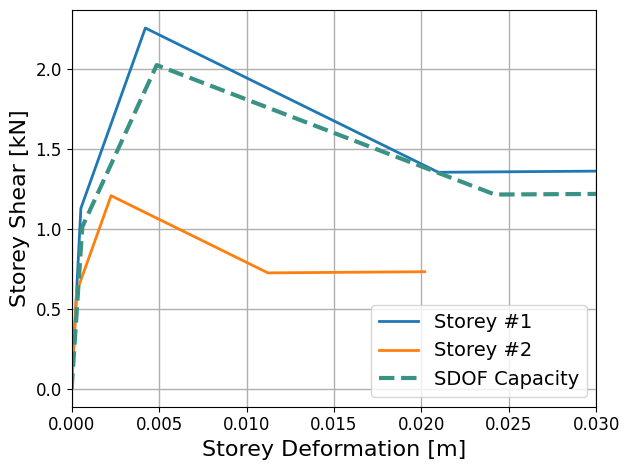

In [6]:
# Calibrate the model using the Lu et al. (2020) method
floor_masses, storey_disps, storey_forces, mdof_phi = calibrate_model(number_storeys, gamma, sdof_capacity, isFrame, isSOS)

# Print statement
print('The mass of each floor (in tonnes):', floor_masses)
print('The first-mode shape used for calibration:', mdof_phi)

# Plot Storey Capacities
for i in range(storey_disps.shape[0]):
    plt.plot(np.concatenate(([0.0], storey_disps[i,:])), 
             np.concatenate(([0.0], storey_forces[i,:] * 9.81)), 
             label=f'Storey #{i+1}', 
             linewidth=LINEWIDTH_2)

# Plot the SDOF Capacity using the custom COLOR and thicker LINEWIDTH
plt.plot(np.concatenate(([0.0], sdof_capacity[:,0])), 
         np.concatenate(([0.0], sdof_capacity[:,1] * 9.81)), 
         label='SDOF Capacity', 
         color=COLOR, 
         linewidth=LINEWIDTH_1, 
         linestyle='--')

# Axis Labels
plt.xlabel('Storey Deformation [m]', fontsize=FONTSIZE_1)
plt.ylabel('Storey Shear [kN]', fontsize=FONTSIZE_1)

# Formatting Ticks
plt.xticks(fontsize=FONTSIZE_3)
plt.yticks(fontsize=FONTSIZE_3)

# Legend and Grid
plt.legend(loc='lower right', fontsize=FONTSIZE_2)
plt.grid(visible=True, which='major', linewidth=LINEWIDTH_3)
plt.grid(visible=True, which='minor', alpha=0.3)

# Plot Limits
plt.xlim([0.00, 0.03])

plt.tight_layout()
plt.show()

## Setting Up, Running MSAs and Exporting Analysis ##

In the next code snippet, MSA is carried out on the stick model using the selected hazard-consistent record sets.

For each ground-motion record, the MDOF model is compiled, gravity-loaded, and subjected to modal analysis to extract its dynamic properties. The ground motion is then applied through NLTHA using consistent time-stepping, appropriate unit scaling, and specified damping.

The analysis extracts key engineering demand parameters (EDPs), including peak storey drifts, peak floor accelerations, and peak floor displacements along the building height. Maximum response values, together with their associated directions and locations, are also recorded. Numerical convergence is monitored through a convergence index.

All response quantities are stored for each record and aggregated into a structured dataset, which is exported for subsequent fragility development, and vulnerability analysis.

======== MSA Analysing RP:22 years, Record 1 out of 20 =========


WARNING ZeroLength::setDomain(): Element 2000 has L= 2.8, which is greater than the tolerance
WARNING ZeroLength::setDomain(): Element 2001 has L= 2.8, which is greater than the tolerance


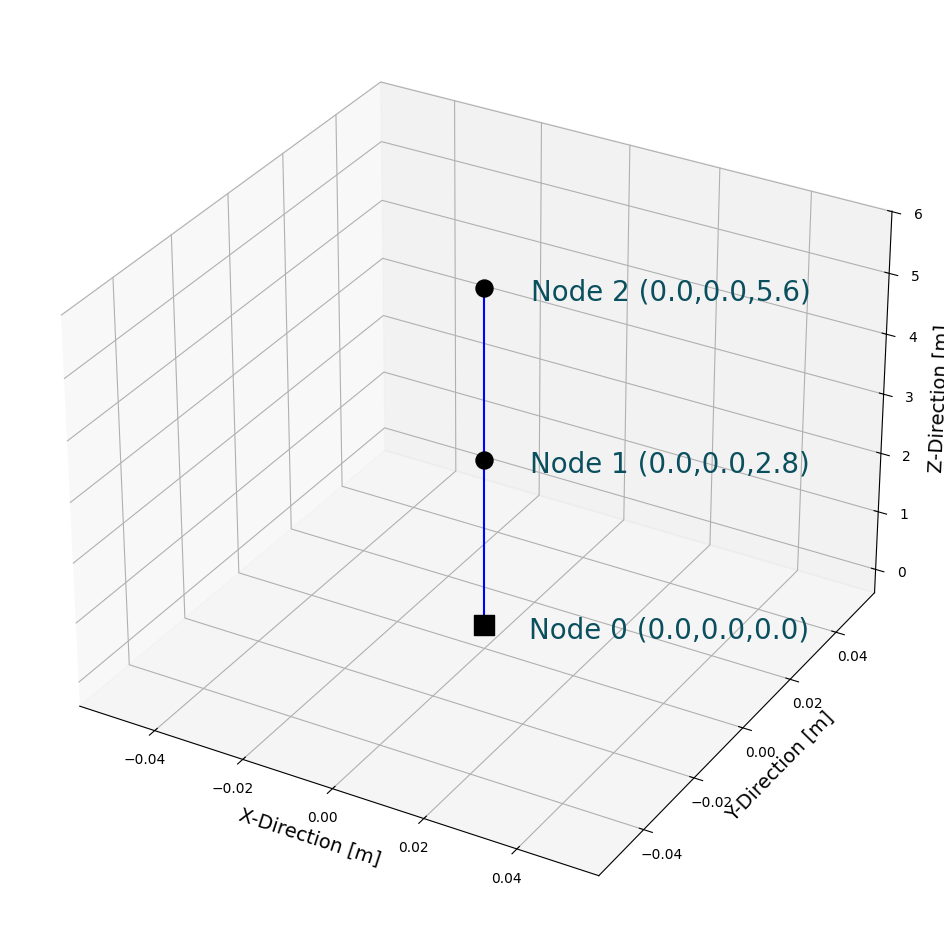

[0.1539994  0.1539994  0.06199133]
~~~~~~~ ANALYSIS SUCCESSFUL ~~~~~~~~~
Peak drift values in X-direction: [9.26921533e-05 5.87664004e-05] rad
Peak drift values in Y-direction: [0. 0.] rad
Peak acceleration values in X-direction: [np.float64(0.0), np.float64(0.0069480719672483), np.float64(0.009163458968479551)] g
Peak acceleration values in Y-direction: [np.float64(0.0), np.float64(0.0), np.float64(0.0)] g
Maximum peak storey drift value of 9.269215326283324e-05 encountered in X direction on storey # 1
Maximum peak floor acceleration value of 0.009163458968479551 encountered in X direction on storey # 2
======== MSA Analysing RP:22 years, Record 2 out of 20 =========
[0.1539994  0.1539994  0.06199133]


WARNING ZeroLength::setDomain(): Element 2000 has L= 2.8, which is greater than the tolerance
WARNING ZeroLength::setDomain(): Element 2001 has L= 2.8, which is greater than the tolerance


~~~~~~~ ANALYSIS SUCCESSFUL ~~~~~~~~~
Peak drift values in X-direction: [8.78464777e-05 6.38417491e-05] rad
Peak drift values in Y-direction: [0. 0.] rad
Peak acceleration values in X-direction: [np.float64(0.0), np.float64(0.004553728602017935), np.float64(0.007982301159843922)] g
Peak acceleration values in Y-direction: [np.float64(0.0), np.float64(0.0), np.float64(0.0)] g
Maximum peak storey drift value of 8.784647770027353e-05 encountered in X direction on storey # 1
Maximum peak floor acceleration value of 0.007982301159843922 encountered in X direction on storey # 2
======== MSA Analysing RP:22 years, Record 3 out of 20 =========
[0.1539994  0.1539994  0.06199133]


WARNING ZeroLength::setDomain(): Element 2000 has L= 2.8, which is greater than the tolerance
WARNING ZeroLength::setDomain(): Element 2001 has L= 2.8, which is greater than the tolerance


~~~~~~~ ANALYSIS SUCCESSFUL ~~~~~~~~~
Peak drift values in X-direction: [6.47980809e-05 1.82068556e-05] rad
Peak drift values in Y-direction: [0. 0.] rad
Peak acceleration values in X-direction: [np.float64(0.0), np.float64(0.002066088451045688), np.float64(0.002147925887218766)] g
Peak acceleration values in Y-direction: [np.float64(0.0), np.float64(0.0), np.float64(0.0)] g
Maximum peak storey drift value of 6.479808085678531e-05 encountered in X direction on storey # 1
Maximum peak floor acceleration value of 0.002147925887218766 encountered in X direction on storey # 2
======== MSA Analysing RP:22 years, Record 4 out of 20 =========
[0.1539994  0.1539994  0.06199133]


...

WARNING ZeroLength::setDomain(): Element 2000 has L= 2.8, which is greater than the tolerance
WARNING ZeroLength::setDomain(): Element 2001 has L= 2.8, which is greater than the tolerance


~~~~~~~ ANALYSIS SUCCESSFUL ~~~~~~~~~
Peak drift values in X-direction: [5.82683390e-05 2.84657141e-05] rad
Peak drift values in Y-direction: [0. 0.] rad
Peak acceleration values in X-direction: [np.float64(0.0), np.float64(0.0022852809242204677), np.float64(0.0033683765129951734)] g
Peak acceleration values in Y-direction: [np.float64(0.0), np.float64(0.0), np.float64(0.0)] g
Maximum peak storey drift value of 5.826833897695237e-05 encountered in X direction on storey # 1
Maximum peak floor acceleration value of 0.0033683765129951734 encountered in X direction on storey # 2
======== MSA Analysing RP:22 years, Record 20 out of 20 =========
[0.1539994  0.1539994  0.06199133]


WARNING ZeroLength::setDomain(): Element 2000 has L= 2.8, which is greater than the tolerance
WARNING ZeroLength::setDomain(): Element 2001 has L= 2.8, which is greater than the tolerance


~~~~~~~ ANALYSIS SUCCESSFUL ~~~~~~~~~
Peak drift values in X-direction: [7.80554430e-05 2.74869681e-05] rad
Peak drift values in Y-direction: [0. 0.] rad
Peak acceleration values in X-direction: [np.float64(0.0), np.float64(0.0020273079407610813), np.float64(0.002540823774316315)] g
Peak acceleration values in Y-direction: [np.float64(0.0), np.float64(0.0), np.float64(0.0)] g
Maximum peak storey drift value of 7.805544297743396e-05 encountered in X direction on storey # 1
Maximum peak floor acceleration value of 0.002540823774316315 encountered in X direction on storey # 2
======== MSA Analysing RP:42 years, Record 1 out of 20 =========


WARNING ZeroLength::setDomain(): Element 2000 has L= 2.8, which is greater than the tolerance
WARNING ZeroLength::setDomain(): Element 2001 has L= 2.8, which is greater than the tolerance


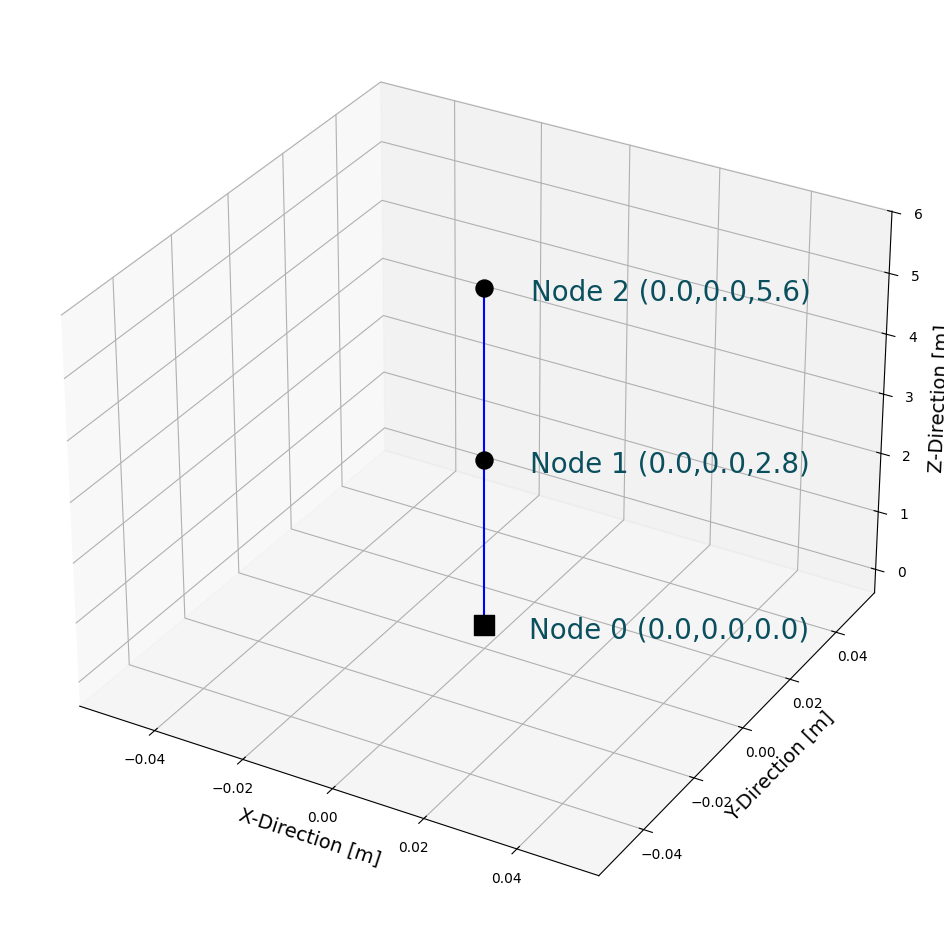

[0.1539994  0.1539994  0.06199133]
~~~~~~~ ANALYSIS SUCCESSFUL ~~~~~~~~~
Peak drift values in X-direction: [1.47563681e-04 6.61093232e-05] rad
Peak drift values in Y-direction: [0. 0.] rad
Peak acceleration values in X-direction: [np.float64(0.0), np.float64(0.001916342689767979), np.float64(0.0030631599120418255)] g
Peak acceleration values in Y-direction: [np.float64(0.0), np.float64(0.0), np.float64(0.0)] g
Maximum peak storey drift value of 0.00014756368149077098 encountered in X direction on storey # 1
Maximum peak floor acceleration value of 0.0030631599120418255 encountered in X direction on storey # 2
======== MSA Analysing RP:42 years, Record 2 out of 20 =========
[0.1539994  0.1539994  0.06199133]


WARNING ZeroLength::setDomain(): Element 2000 has L= 2.8, which is greater than the tolerance
WARNING ZeroLength::setDomain(): Element 2001 has L= 2.8, which is greater than the tolerance


~~~~~~~ ANALYSIS SUCCESSFUL ~~~~~~~~~
Peak drift values in X-direction: [1.22958439e-04 6.23145065e-05] rad
Peak drift values in Y-direction: [0. 0.] rad
Peak acceleration values in X-direction: [np.float64(0.0), np.float64(0.005002964040418698), np.float64(0.0073648231870236175)] g
Peak acceleration values in Y-direction: [np.float64(0.0), np.float64(0.0), np.float64(0.0)] g
Maximum peak storey drift value of 0.00012295843945836965 encountered in X direction on storey # 1
Maximum peak floor acceleration value of 0.0073648231870236175 encountered in X direction on storey # 2
======== MSA Analysing RP:42 years, Record 3 out of 20 =========
[0.1539994  0.1539994  0.06199133]
~~~~~~~ ANALYSIS SUCCESSFUL ~~~~~~~~~
Peak drift values in X-direction: [1.28227330e-04 6.84138207e-05] rad
Peak drift values in Y-direction: [0. 0.] rad
Peak acceleration values in X-direction: [np.float64(0.0), np.float64(0.00444804794250956), np.float64(0.0067746386883503875)] g
Peak acceleration values in Y-direc

WARNING ZeroLength::setDomain(): Element 2000 has L= 2.8, which is greater than the tolerance
WARNING ZeroLength::setDomain(): Element 2001 has L= 2.8, which is greater than the tolerance
WARNING ZeroLength::setDomain(): Element 2000 has L= 2.8, which is greater than the tolerance
WARNING ZeroLength::setDomain(): Element 2001 has L= 2.8, which is greater than the tolerance


~~~~~~~ ANALYSIS SUCCESSFUL ~~~~~~~~~
Peak drift values in X-direction: [1.19649556e-04 6.29450825e-05] rad
Peak drift values in Y-direction: [0. 0.] rad
Peak acceleration values in X-direction: [np.float64(0.0), np.float64(0.002849895122698918), np.float64(0.00500271369919402)] g
Peak acceleration values in Y-direction: [np.float64(0.0), np.float64(0.0), np.float64(0.0)] g
Maximum peak storey drift value of 0.00011964955648809854 encountered in X direction on storey # 1
Maximum peak floor acceleration value of 0.00500271369919402 encountered in X direction on storey # 2
======== MSA Analysing RP:42 years, Record 5 out of 20 =========
[0.1539994  0.1539994  0.06199133]


...

WARNING ZeroLength::setDomain(): Element 2000 has L= 2.8, which is greater than the tolerance
WARNING ZeroLength::setDomain(): Element 2001 has L= 2.8, which is greater than the tolerance


~~~~~~~ ANALYSIS SUCCESSFUL ~~~~~~~~~
Peak drift values in X-direction: [1.26683271e-04 7.13188956e-05] rad
Peak drift values in Y-direction: [0. 0.] rad
Peak acceleration values in X-direction: [np.float64(0.0), np.float64(0.003927146525498758), np.float64(0.005664717945786191)] g
Peak acceleration values in Y-direction: [np.float64(0.0), np.float64(0.0), np.float64(0.0)] g
Maximum peak storey drift value of 0.00012668327071816194 encountered in X direction on storey # 1
Maximum peak floor acceleration value of 0.005664717945786191 encountered in X direction on storey # 2
======== MSA Analysing RP:42 years, Record 20 out of 20 =========
[0.1539994  0.1539994  0.06199133]


WARNING ZeroLength::setDomain(): Element 2000 has L= 2.8, which is greater than the tolerance
WARNING ZeroLength::setDomain(): Element 2001 has L= 2.8, which is greater than the tolerance


~~~~~~~ ANALYSIS SUCCESSFUL ~~~~~~~~~
Peak drift values in X-direction: [1.77681922e-04 9.78724710e-05] rad
Peak drift values in Y-direction: [0. 0.] rad
Peak acceleration values in X-direction: [np.float64(0.0), np.float64(0.01146393128637081), np.float64(0.014344871423152484)] g
Peak acceleration values in Y-direction: [np.float64(0.0), np.float64(0.0), np.float64(0.0)] g
Maximum peak storey drift value of 0.00017768192218780264 encountered in X direction on storey # 1
Maximum peak floor acceleration value of 0.014344871423152484 encountered in X direction on storey # 2
======== MSA Analysing RP:72 years, Record 1 out of 20 =========


WARNING ZeroLength::setDomain(): Element 2000 has L= 2.8, which is greater than the tolerance
WARNING ZeroLength::setDomain(): Element 2001 has L= 2.8, which is greater than the tolerance


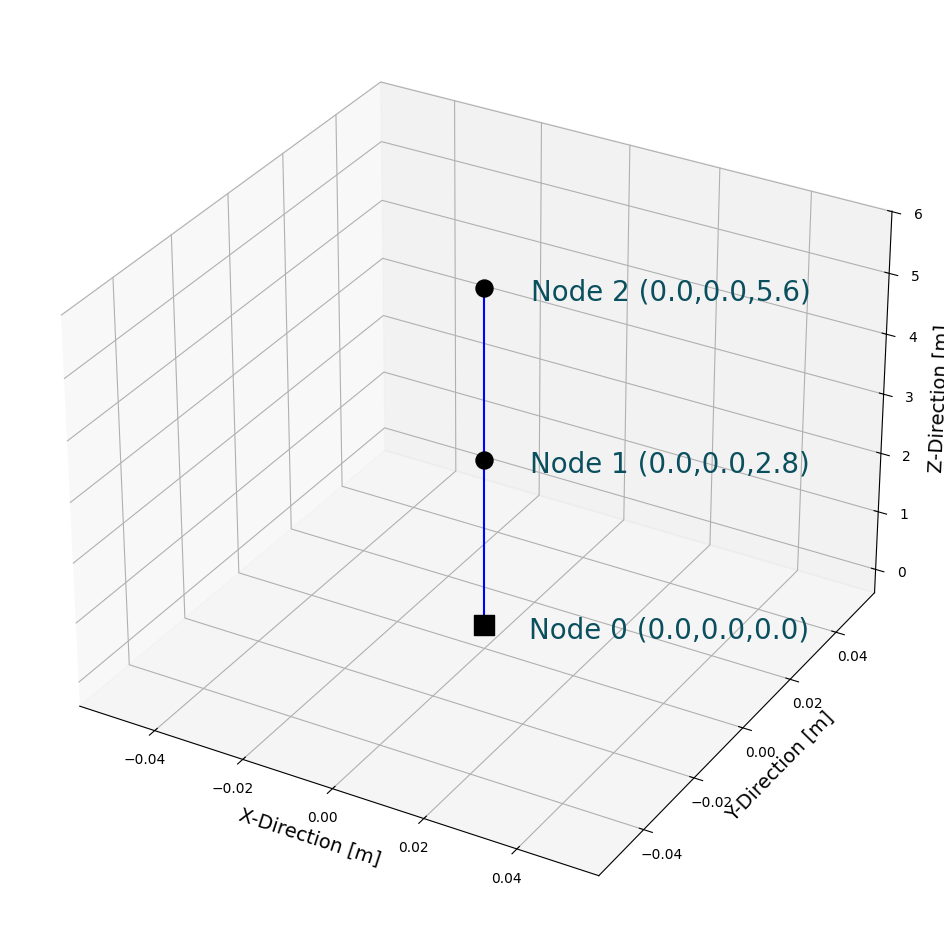

[0.1539994  0.1539994  0.06199133]
~~~~~~~ ANALYSIS SUCCESSFUL ~~~~~~~~~
Peak drift values in X-direction: [0.000235   0.00014801] rad
Peak drift values in Y-direction: [0. 0.] rad
Peak acceleration values in X-direction: [np.float64(0.0), np.float64(0.00833209429070855), np.float64(0.013800740393365919)] g
Peak acceleration values in Y-direction: [np.float64(0.0), np.float64(0.0), np.float64(0.0)] g
Maximum peak storey drift value of 0.0002350038910660843 encountered in X direction on storey # 1
Maximum peak floor acceleration value of 0.013800740393365919 encountered in X direction on storey # 2
======== MSA Analysing RP:72 years, Record 2 out of 20 =========
[0.1539994  0.1539994  0.06199133]


WARNING ZeroLength::setDomain(): Element 2000 has L= 2.8, which is greater than the tolerance
WARNING ZeroLength::setDomain(): Element 2001 has L= 2.8, which is greater than the tolerance


~~~~~~~ ANALYSIS SUCCESSFUL ~~~~~~~~~
Peak drift values in X-direction: [0.00017989 0.00017222] rad
Peak drift values in Y-direction: [0. 0.] rad
Peak acceleration values in X-direction: [np.float64(0.0), np.float64(0.011665228020652113), np.float64(0.025781509007650825)] g
Peak acceleration values in Y-direction: [np.float64(0.0), np.float64(0.0), np.float64(0.0)] g
Maximum peak storey drift value of 0.00017989480248001242 encountered in X direction on storey # 1
Maximum peak floor acceleration value of 0.025781509007650825 encountered in X direction on storey # 2
======== MSA Analysing RP:72 years, Record 3 out of 20 =========
[0.1539994  0.1539994  0.06199133]


WARNING ZeroLength::setDomain(): Element 2000 has L= 2.8, which is greater than the tolerance
WARNING ZeroLength::setDomain(): Element 2001 has L= 2.8, which is greater than the tolerance


~~~~~~~ ANALYSIS SUCCESSFUL ~~~~~~~~~
Peak drift values in X-direction: [0.00021699 0.00011576] rad
Peak drift values in Y-direction: [0. 0.] rad
Peak acceleration values in X-direction: [np.float64(0.0), np.float64(0.007186445070688504), np.float64(0.01127948984123243)] g
Peak acceleration values in Y-direction: [np.float64(0.0), np.float64(0.0), np.float64(0.0)] g
Maximum peak storey drift value of 0.0002169889831477775 encountered in X direction on storey # 1
Maximum peak floor acceleration value of 0.01127948984123243 encountered in X direction on storey # 2
======== MSA Analysing RP:72 years, Record 4 out of 20 =========
[0.1539994  0.1539994  0.06199133]


...

WARNING ZeroLength::setDomain(): Element 2000 has L= 2.8, which is greater than the tolerance
WARNING ZeroLength::setDomain(): Element 2001 has L= 2.8, which is greater than the tolerance


~~~~~~~ ANALYSIS SUCCESSFUL ~~~~~~~~~
Peak drift values in X-direction: [0.00038684 0.00012112] rad
Peak drift values in Y-direction: [0. 0.] rad
Peak acceleration values in X-direction: [np.float64(0.0), np.float64(0.01230821222206805), np.float64(0.015762180365834516)] g
Peak acceleration values in Y-direction: [np.float64(0.0), np.float64(0.0), np.float64(0.0)] g
Maximum peak storey drift value of 0.00038683885532303665 encountered in X direction on storey # 1
Maximum peak floor acceleration value of 0.015762180365834516 encountered in X direction on storey # 2
======== MSA Analysing RP:72 years, Record 20 out of 20 =========
[0.1539994  0.1539994  0.06199133]


WARNING ZeroLength::setDomain(): Element 2000 has L= 2.8, which is greater than the tolerance
WARNING ZeroLength::setDomain(): Element 2001 has L= 2.8, which is greater than the tolerance


~~~~~~~ ANALYSIS SUCCESSFUL ~~~~~~~~~
Peak drift values in X-direction: [0.00022524 0.00010531] rad
Peak drift values in Y-direction: [0. 0.] rad
Peak acceleration values in X-direction: [np.float64(0.0), np.float64(0.007923794794988556), np.float64(0.010780422085832212)] g
Peak acceleration values in Y-direction: [np.float64(0.0), np.float64(0.0), np.float64(0.0)] g
Maximum peak storey drift value of 0.00022523989804617675 encountered in X direction on storey # 1
Maximum peak floor acceleration value of 0.010780422085832212 encountered in X direction on storey # 2
======== MSA Analysing RP:140 years, Record 1 out of 20 =========


WARNING ZeroLength::setDomain(): Element 2000 has L= 2.8, which is greater than the tolerance
WARNING ZeroLength::setDomain(): Element 2001 has L= 2.8, which is greater than the tolerance


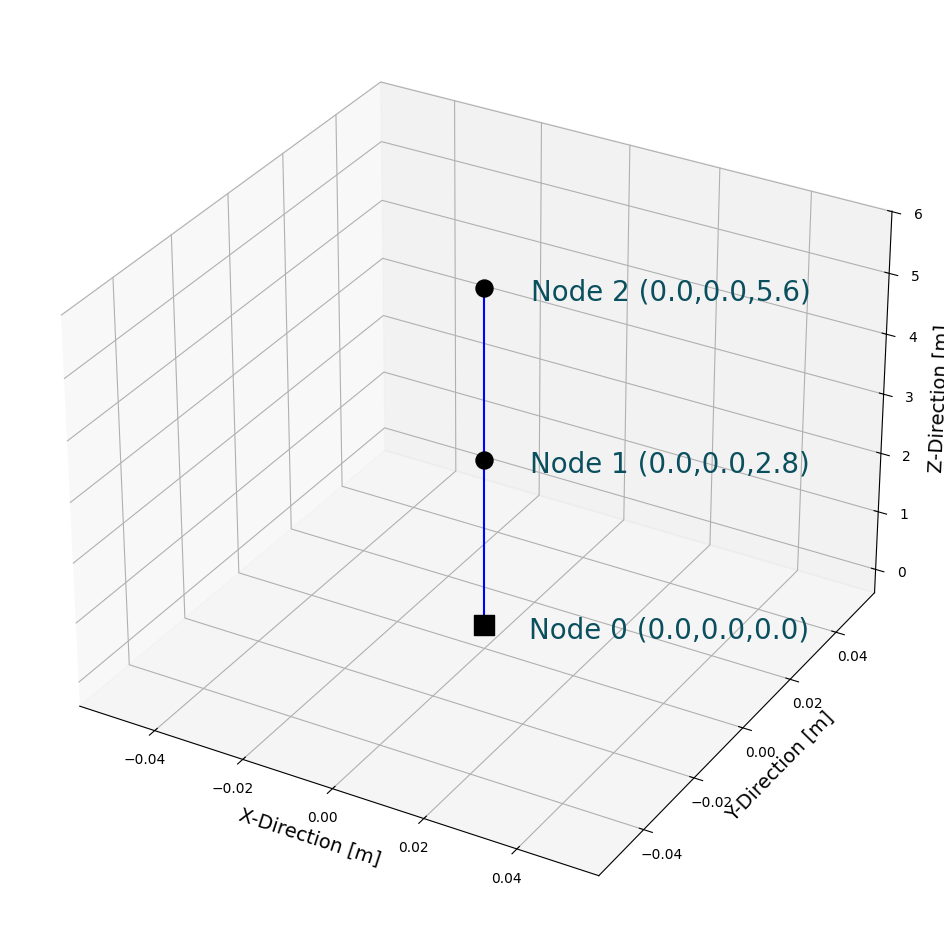

[0.1539994  0.1539994  0.06199133]
~~~~~~~ ANALYSIS SUCCESSFUL ~~~~~~~~~
Peak drift values in X-direction: [0.00041468 0.00021562] rad
Peak drift values in Y-direction: [0. 0.] rad
Peak acceleration values in X-direction: [np.float64(0.0), np.float64(0.01468540961867046), np.float64(0.020641910121495716)] g
Peak acceleration values in Y-direction: [np.float64(0.0), np.float64(0.0), np.float64(0.0)] g
Maximum peak storey drift value of 0.000414678235218636 encountered in X direction on storey # 1
Maximum peak floor acceleration value of 0.020641910121495716 encountered in X direction on storey # 2
======== MSA Analysing RP:140 years, Record 2 out of 20 =========
[0.1539994  0.1539994  0.06199133]


WARNING ZeroLength::setDomain(): Element 2000 has L= 2.8, which is greater than the tolerance
WARNING ZeroLength::setDomain(): Element 2001 has L= 2.8, which is greater than the tolerance


~~~~~~~ ANALYSIS SUCCESSFUL ~~~~~~~~~
Peak drift values in X-direction: [0.00043518 0.0001569 ] rad
Peak drift values in Y-direction: [0. 0.] rad
Peak acceleration values in X-direction: [np.float64(0.0), np.float64(0.018440370941744288), np.float64(0.015774190864693536)] g
Peak acceleration values in Y-direction: [np.float64(0.0), np.float64(0.0), np.float64(0.0)] g
Maximum peak storey drift value of 0.0004351846480847711 encountered in X direction on storey # 1
Maximum peak floor acceleration value of 0.018440370941744288 encountered in X direction on storey # 1
======== MSA Analysing RP:140 years, Record 3 out of 20 =========
[0.1539994  0.1539994  0.06199133]


WARNING ZeroLength::setDomain(): Element 2000 has L= 2.8, which is greater than the tolerance
WARNING ZeroLength::setDomain(): Element 2001 has L= 2.8, which is greater than the tolerance


~~~~~~~ ANALYSIS SUCCESSFUL ~~~~~~~~~
Peak drift values in X-direction: [0.00030872 0.00031425] rad
Peak drift values in Y-direction: [0. 0.] rad
Peak acceleration values in X-direction: [np.float64(0.0), np.float64(0.016066834391137604), np.float64(0.022734349974882766)] g
Peak acceleration values in Y-direction: [np.float64(0.0), np.float64(0.0), np.float64(0.0)] g
Maximum peak storey drift value of 0.00031425456742897564 encountered in X direction on storey # 2
Maximum peak floor acceleration value of 0.022734349974882766 encountered in X direction on storey # 2
======== MSA Analysing RP:140 years, Record 4 out of 20 =========
[0.1539994  0.1539994  0.06199133]


...

WARNING ZeroLength::setDomain(): Element 2000 has L= 2.8, which is greater than the tolerance
WARNING ZeroLength::setDomain(): Element 2001 has L= 2.8, which is greater than the tolerance


~~~~~~~ ANALYSIS SUCCESSFUL ~~~~~~~~~
Peak drift values in X-direction: [0.00049297 0.00024913] rad
Peak drift values in Y-direction: [0. 0.] rad
Peak acceleration values in X-direction: [np.float64(0.0), np.float64(0.0126996386196253), np.float64(0.0182272974563499)] g
Peak acceleration values in Y-direction: [np.float64(0.0), np.float64(0.0), np.float64(0.0)] g
Maximum peak storey drift value of 0.0004929658524991069 encountered in X direction on storey # 1
Maximum peak floor acceleration value of 0.0182272974563499 encountered in X direction on storey # 2
======== MSA Analysing RP:140 years, Record 20 out of 20 =========
[0.1539994  0.1539994  0.06199133]


WARNING ZeroLength::setDomain(): Element 2000 has L= 2.8, which is greater than the tolerance
WARNING ZeroLength::setDomain(): Element 2001 has L= 2.8, which is greater than the tolerance


~~~~~~~ ANALYSIS SUCCESSFUL ~~~~~~~~~
Peak drift values in X-direction: [0.00042514 0.00017335] rad
Peak drift values in Y-direction: [0. 0.] rad
Peak acceleration values in X-direction: [np.float64(0.0), np.float64(0.021066525564116475), np.float64(0.019573483052370298)] g
Peak acceleration values in Y-direction: [np.float64(0.0), np.float64(0.0), np.float64(0.0)] g
Maximum peak storey drift value of 0.0004251422217655274 encountered in X direction on storey # 1
Maximum peak floor acceleration value of 0.021066525564116475 encountered in X direction on storey # 1
======== MSA Analysing RP:224 years, Record 1 out of 20 =========


WARNING ZeroLength::setDomain(): Element 2000 has L= 2.8, which is greater than the tolerance
WARNING ZeroLength::setDomain(): Element 2001 has L= 2.8, which is greater than the tolerance


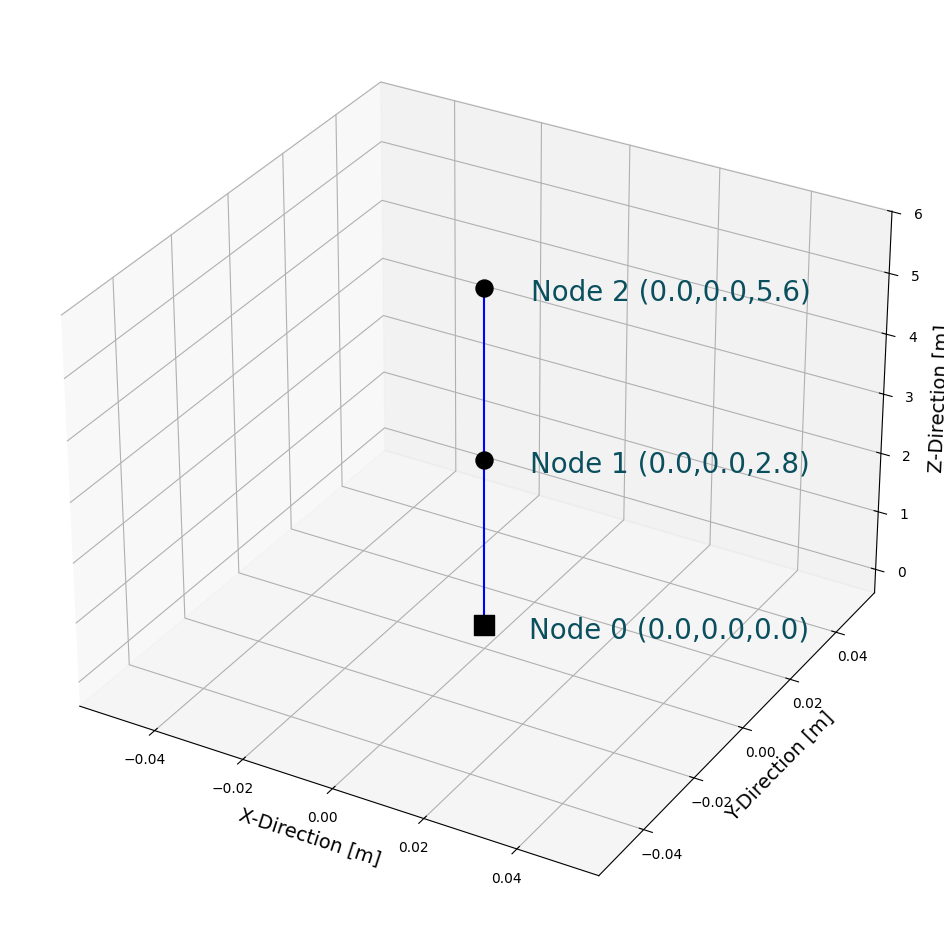

[0.1539994  0.1539994  0.06199133]
~~~~~~~ ANALYSIS SUCCESSFUL ~~~~~~~~~
Peak drift values in X-direction: [0.00044993 0.00035343] rad
Peak drift values in Y-direction: [0. 0.] rad
Peak acceleration values in X-direction: [np.float64(0.0), np.float64(0.022724903048701284), np.float64(0.03254332417270451)] g
Peak acceleration values in Y-direction: [np.float64(0.0), np.float64(0.0), np.float64(0.0)] g
Maximum peak storey drift value of 0.00044993198553885055 encountered in X direction on storey # 1
Maximum peak floor acceleration value of 0.03254332417270451 encountered in X direction on storey # 2
======== MSA Analysing RP:224 years, Record 2 out of 20 =========
[0.1539994  0.1539994  0.06199133]


WARNING ZeroLength::setDomain(): Element 2000 has L= 2.8, which is greater than the tolerance
WARNING ZeroLength::setDomain(): Element 2001 has L= 2.8, which is greater than the tolerance


~~~~~~~ ANALYSIS SUCCESSFUL ~~~~~~~~~
Peak drift values in X-direction: [0.00051978 0.00040457] rad
Peak drift values in Y-direction: [0. 0.] rad
Peak acceleration values in X-direction: [np.float64(0.0), np.float64(0.013661635504929354), np.float64(0.02321631562758186)] g
Peak acceleration values in Y-direction: [np.float64(0.0), np.float64(0.0), np.float64(0.0)] g
Maximum peak storey drift value of 0.0005197823735837063 encountered in X direction on storey # 1
Maximum peak floor acceleration value of 0.02321631562758186 encountered in X direction on storey # 2
======== MSA Analysing RP:224 years, Record 3 out of 20 =========
[0.1539994  0.1539994  0.06199133]


WARNING ZeroLength::setDomain(): Element 2000 has L= 2.8, which is greater than the tolerance
WARNING ZeroLength::setDomain(): Element 2001 has L= 2.8, which is greater than the tolerance


~~~~~~~ ANALYSIS SUCCESSFUL ~~~~~~~~~
Peak drift values in X-direction: [0.00060646 0.00018251] rad
Peak drift values in Y-direction: [0. 0.] rad
Peak acceleration values in X-direction: [np.float64(0.0), np.float64(0.020148132464806456), np.float64(0.018318317514160114)] g
Peak acceleration values in Y-direction: [np.float64(0.0), np.float64(0.0), np.float64(0.0)] g
Maximum peak storey drift value of 0.0006064644609647703 encountered in X direction on storey # 1
Maximum peak floor acceleration value of 0.020148132464806456 encountered in X direction on storey # 1
======== MSA Analysing RP:224 years, Record 4 out of 20 =========
[0.1539994  0.1539994  0.06199133]


...

WARNING ZeroLength::setDomain(): Element 2000 has L= 2.8, which is greater than the tolerance
WARNING ZeroLength::setDomain(): Element 2001 has L= 2.8, which is greater than the tolerance


~~~~~~~ ANALYSIS SUCCESSFUL ~~~~~~~~~
Peak drift values in X-direction: [0.00096627 0.00046548] rad
Peak drift values in Y-direction: [0. 0.] rad
Peak acceleration values in X-direction: [np.float64(0.0), np.float64(0.0156981762862811), np.float64(0.02092922145084906)] g
Peak acceleration values in Y-direction: [np.float64(0.0), np.float64(0.0), np.float64(0.0)] g
Maximum peak storey drift value of 0.0009662702867622854 encountered in X direction on storey # 1
Maximum peak floor acceleration value of 0.02092922145084906 encountered in X direction on storey # 2
======== MSA Analysing RP:224 years, Record 20 out of 20 =========
[0.1539994  0.1539994  0.06199133]


WARNING ZeroLength::setDomain(): Element 2000 has L= 2.8, which is greater than the tolerance
WARNING ZeroLength::setDomain(): Element 2001 has L= 2.8, which is greater than the tolerance


~~~~~~~ ANALYSIS SUCCESSFUL ~~~~~~~~~
Peak drift values in X-direction: [0.00090565 0.00034907] rad
Peak drift values in Y-direction: [0. 0.] rad
Peak acceleration values in X-direction: [np.float64(0.0), np.float64(0.017590113855741538), np.float64(0.024258190135736754)] g
Peak acceleration values in Y-direction: [np.float64(0.0), np.float64(0.0), np.float64(0.0)] g
Maximum peak storey drift value of 0.0009056526653830663 encountered in X direction on storey # 1
Maximum peak floor acceleration value of 0.024258190135736754 encountered in X direction on storey # 2
======== MSA Analysing RP:475 years, Record 1 out of 20 =========


WARNING ZeroLength::setDomain(): Element 2000 has L= 2.8, which is greater than the tolerance
WARNING ZeroLength::setDomain(): Element 2001 has L= 2.8, which is greater than the tolerance


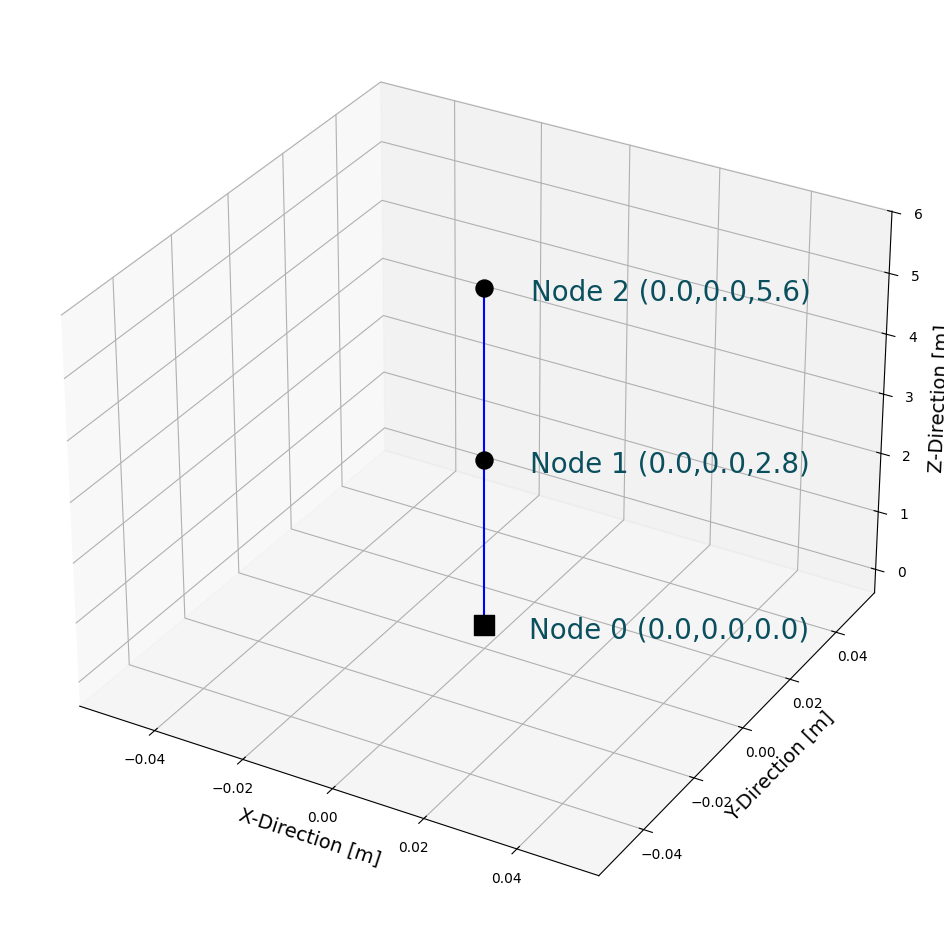

[0.1539994  0.1539994  0.06199133]
~~~~~~~ ANALYSIS SUCCESSFUL ~~~~~~~~~
Peak drift values in X-direction: [0.00055765 0.00040476] rad
Peak drift values in Y-direction: [0. 0.] rad
Peak acceleration values in X-direction: [np.float64(0.0), np.float64(0.02191084997913953), np.float64(0.03714601408688571)] g
Peak acceleration values in Y-direction: [np.float64(0.0), np.float64(0.0), np.float64(0.0)] g
Maximum peak storey drift value of 0.0005576545152860087 encountered in X direction on storey # 1
Maximum peak floor acceleration value of 0.03714601408688571 encountered in X direction on storey # 2
======== MSA Analysing RP:475 years, Record 2 out of 20 =========
[0.1539994  0.1539994  0.06199133]


WARNING ZeroLength::setDomain(): Element 2000 has L= 2.8, which is greater than the tolerance
WARNING ZeroLength::setDomain(): Element 2001 has L= 2.8, which is greater than the tolerance


~~~~~~~ ANALYSIS SUCCESSFUL ~~~~~~~~~
Peak drift values in X-direction: [0.00066153 0.00055804] rad
Peak drift values in Y-direction: [0. 0.] rad
Peak acceleration values in X-direction: [np.float64(0.0), np.float64(0.019777478302825335), np.float64(0.03405686252840903)] g
Peak acceleration values in Y-direction: [np.float64(0.0), np.float64(0.0), np.float64(0.0)] g
Maximum peak storey drift value of 0.0006615307604985351 encountered in X direction on storey # 1
Maximum peak floor acceleration value of 0.03405686252840903 encountered in X direction on storey # 2
======== MSA Analysing RP:475 years, Record 3 out of 20 =========
[0.1539994  0.1539994  0.06199133]


WARNING ZeroLength::setDomain(): Element 2000 has L= 2.8, which is greater than the tolerance
WARNING ZeroLength::setDomain(): Element 2001 has L= 2.8, which is greater than the tolerance


~~~~~~~ ANALYSIS SUCCESSFUL ~~~~~~~~~
Peak drift values in X-direction: [0.00121251 0.00033692] rad
Peak drift values in Y-direction: [0. 0.] rad
Peak acceleration values in X-direction: [np.float64(0.0), np.float64(0.031698479785242276), np.float64(0.03307547647958406)] g
Peak acceleration values in Y-direction: [np.float64(0.0), np.float64(0.0), np.float64(0.0)] g
Maximum peak storey drift value of 0.0012125135678696087 encountered in X direction on storey # 1
Maximum peak floor acceleration value of 0.03307547647958406 encountered in X direction on storey # 2
======== MSA Analysing RP:475 years, Record 4 out of 20 =========
[0.1539994  0.1539994  0.06199133]
~~~~~~~ ANALYSIS SUCCESSFUL ~~~~~~~~~
Peak drift values in X-direction: [0.00084498 0.00034504] rad
Peak drift values in Y-direction: [0. 0.] rad
Peak acceleration values in X-direction: [np.float64(0.0), np.float64(0.02280230441530702), np.float64(0.02854350147372548)] g
Peak acceleration values in Y-direction: [np.float64(0.0)

...

WARNING ZeroLength::setDomain(): Element 2000 has L= 2.8, which is greater than the tolerance
WARNING ZeroLength::setDomain(): Element 2001 has L= 2.8, which is greater than the tolerance
WARNING ZeroLength::setDomain(): Element 2000 has L= 2.8, which is greater than the tolerance
WARNING ZeroLength::setDomain(): Element 2001 has L= 2.8, which is greater than the tolerance


~~~~~~~ ANALYSIS SUCCESSFUL ~~~~~~~~~
Peak drift values in X-direction: [0.00136494 0.00093862] rad
Peak drift values in Y-direction: [0. 0.] rad
Peak acceleration values in X-direction: [np.float64(0.0), np.float64(0.030151294828316726), np.float64(0.039552276056373604)] g
Peak acceleration values in Y-direction: [np.float64(0.0), np.float64(0.0), np.float64(0.0)] g
Maximum peak storey drift value of 0.001364941333104399 encountered in X direction on storey # 1
Maximum peak floor acceleration value of 0.039552276056373604 encountered in X direction on storey # 2
======== MSA Analysing RP:475 years, Record 20 out of 20 =========
[0.1539994  0.1539994  0.06199133]


WARNING ZeroLength::setDomain(): Element 2000 has L= 2.8, which is greater than the tolerance
WARNING ZeroLength::setDomain(): Element 2001 has L= 2.8, which is greater than the tolerance


~~~~~~~ ANALYSIS SUCCESSFUL ~~~~~~~~~
Peak drift values in X-direction: [0.00091255 0.0007659 ] rad
Peak drift values in Y-direction: [0. 0.] rad
Peak acceleration values in X-direction: [np.float64(0.0), np.float64(0.026606435971081074), np.float64(0.0362176783711607)] g
Peak acceleration values in Y-direction: [np.float64(0.0), np.float64(0.0), np.float64(0.0)] g
Maximum peak storey drift value of 0.0009125520535468906 encountered in X direction on storey # 1
Maximum peak floor acceleration value of 0.0362176783711607 encountered in X direction on storey # 2
======== MSA Analysing RP:975 years, Record 1 out of 20 =========


WARNING ZeroLength::setDomain(): Element 2000 has L= 2.8, which is greater than the tolerance
WARNING ZeroLength::setDomain(): Element 2001 has L= 2.8, which is greater than the tolerance


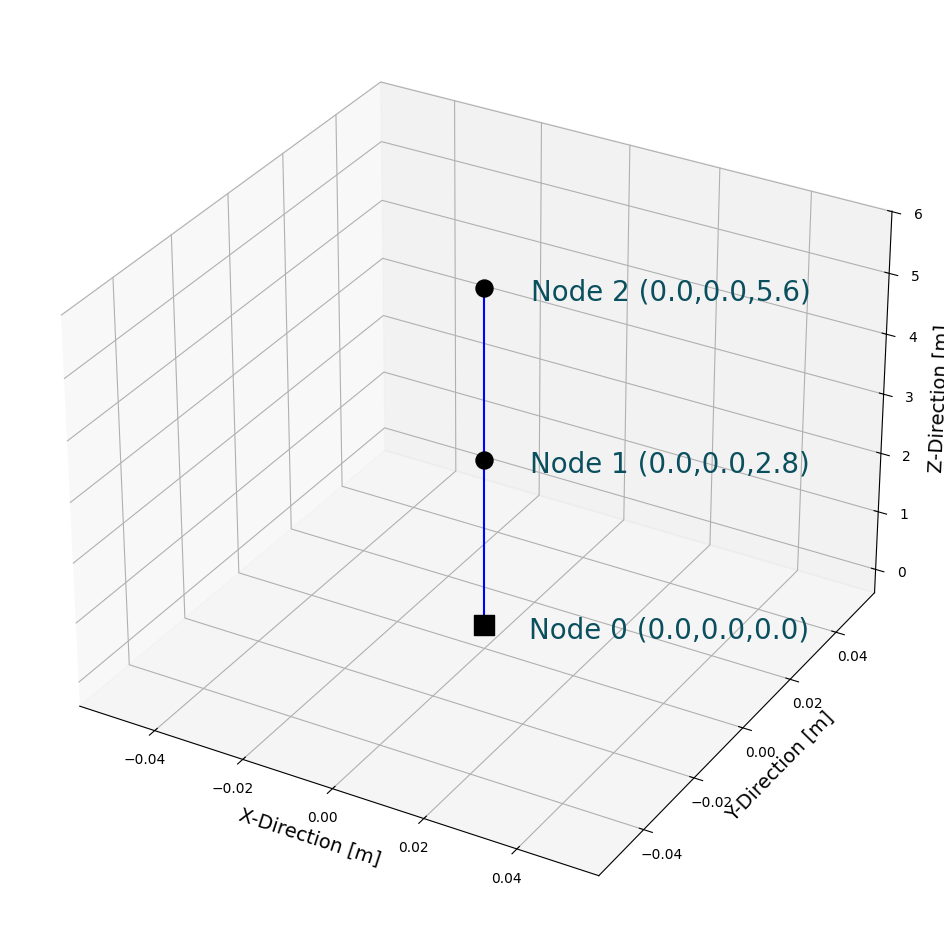

[0.1539994  0.1539994  0.06199133]
~~~~~~~ ANALYSIS SUCCESSFUL ~~~~~~~~~
Peak drift values in X-direction: [0.0571373  0.02991621] rad
Peak drift values in Y-direction: [0. 0.] rad
Peak acceleration values in X-direction: [np.float64(0.0), np.float64(0.04118506285001812), np.float64(0.04543811037529901)] g
Peak acceleration values in Y-direction: [np.float64(0.0), np.float64(0.0), np.float64(0.0)] g
Maximum peak storey drift value of 0.057137295407100594 encountered in X direction on storey # 1
Maximum peak floor acceleration value of 0.04543811037529901 encountered in X direction on storey # 2
======== MSA Analysing RP:975 years, Record 2 out of 20 =========
[0.1539994  0.06199133 0.06199133]


WARNING ZeroLength::setDomain(): Element 2000 has L= 2.8, which is greater than the tolerance
WARNING ZeroLength::setDomain(): Element 2001 has L= 2.8, which is greater than the tolerance


~~~~~~~ ANALYSIS SUCCESSFUL ~~~~~~~~~
Peak drift values in X-direction: [0.00069216 0.00058366] rad
Peak drift values in Y-direction: [0. 0.] rad
Peak acceleration values in X-direction: [np.float64(0.0), np.float64(0.02961166803472346), np.float64(0.04615328441276529)] g
Peak acceleration values in Y-direction: [np.float64(0.0), np.float64(0.0), np.float64(0.0)] g
Maximum peak storey drift value of 0.000692157038967668 encountered in X direction on storey # 1
Maximum peak floor acceleration value of 0.04615328441276529 encountered in X direction on storey # 2
======== MSA Analysing RP:975 years, Record 3 out of 20 =========
[0.1539994  0.1539994  0.06199133]


WARNING ZeroLength::setDomain(): Element 2000 has L= 2.8, which is greater than the tolerance
WARNING ZeroLength::setDomain(): Element 2001 has L= 2.8, which is greater than the tolerance


~~~~~~~ ANALYSIS SUCCESSFUL ~~~~~~~~~
Peak drift values in X-direction: [0.00090371 0.00078783] rad
Peak drift values in Y-direction: [0. 0.] rad
Peak acceleration values in X-direction: [np.float64(0.0), np.float64(0.020886055363627365), np.float64(0.028630105020261146)] g
Peak acceleration values in Y-direction: [np.float64(0.0), np.float64(0.0), np.float64(0.0)] g
Maximum peak storey drift value of 0.00090371049341841 encountered in X direction on storey # 1
Maximum peak floor acceleration value of 0.028630105020261146 encountered in X direction on storey # 2
======== MSA Analysing RP:975 years, Record 4 out of 20 =========
[0.1539994  0.1539994  0.06199133]
~~~~~~~ ANALYSIS SUCCESSFUL ~~~~~~~~~
Peak drift values in X-direction: [0.00150878 0.00143747] rad
Peak drift values in Y-direction: [0. 0.] rad
Peak acceleration values in X-direction: [np.float64(0.0), np.float64(0.03614586573487006), np.float64(0.04420565625826014)] g
Peak acceleration values in Y-direction: [np.float64(0.0)

...

WARNING ZeroLength::setDomain(): Element 2000 has L= 2.8, which is greater than the tolerance
WARNING ZeroLength::setDomain(): Element 2001 has L= 2.8, which is greater than the tolerance
WARNING ZeroLength::setDomain(): Element 2000 has L= 2.8, which is greater than the tolerance
WARNING ZeroLength::setDomain(): Element 2001 has L= 2.8, which is greater than the tolerance


~~~~~~~ ANALYSIS SUCCESSFUL ~~~~~~~~~
Peak drift values in X-direction: [0.00104387 0.00100713] rad
Peak drift values in Y-direction: [0. 0.] rad
Peak acceleration values in X-direction: [np.float64(0.0), np.float64(0.019728939444910873), np.float64(0.035599695029958196)] g
Peak acceleration values in Y-direction: [np.float64(0.0), np.float64(0.0), np.float64(0.0)] g
Maximum peak storey drift value of 0.0010438682787401819 encountered in X direction on storey # 1
Maximum peak floor acceleration value of 0.035599695029958196 encountered in X direction on storey # 2
======== MSA Analysing RP:975 years, Record 18 out of 20 =========
[0.1539994  0.1539994  0.06199133]
~~~~~~~ ANALYSIS SUCCESSFUL ~~~~~~~~~
Peak drift values in X-direction: [0.00127949 0.00145547] rad
Peak drift values in Y-direction: [0. 0.] rad
Peak acceleration values in X-direction: [np.float64(0.0), np.float64(0.042186467974564344), np.float64(0.03562798109603568)] g
Peak acceleration values in Y-direction: [np.float64(

WARNING ZeroLength::setDomain(): Element 2000 has L= 2.8, which is greater than the tolerance
WARNING ZeroLength::setDomain(): Element 2001 has L= 2.8, which is greater than the tolerance
WARNING ZeroLength::setDomain(): Element 2000 has L= 2.8, which is greater than the tolerance
WARNING ZeroLength::setDomain(): Element 2001 has L= 2.8, which is greater than the tolerance


~~~~~~~ ANALYSIS SUCCESSFUL ~~~~~~~~~
Peak drift values in X-direction: [0.00166202 0.00073057] rad
Peak drift values in Y-direction: [0. 0.] rad
Peak acceleration values in X-direction: [np.float64(0.0), np.float64(0.029183955876965584), np.float64(0.037320923511512026)] g
Peak acceleration values in Y-direction: [np.float64(0.0), np.float64(0.0), np.float64(0.0)] g
Maximum peak storey drift value of 0.0016620153332542707 encountered in X direction on storey # 1
Maximum peak floor acceleration value of 0.037320923511512026 encountered in X direction on storey # 2
======== MSA Analysing RP:2475 years, Record 1 out of 20 =========


WARNING ZeroLength::setDomain(): Element 2000 has L= 2.8, which is greater than the tolerance
WARNING ZeroLength::setDomain(): Element 2001 has L= 2.8, which is greater than the tolerance


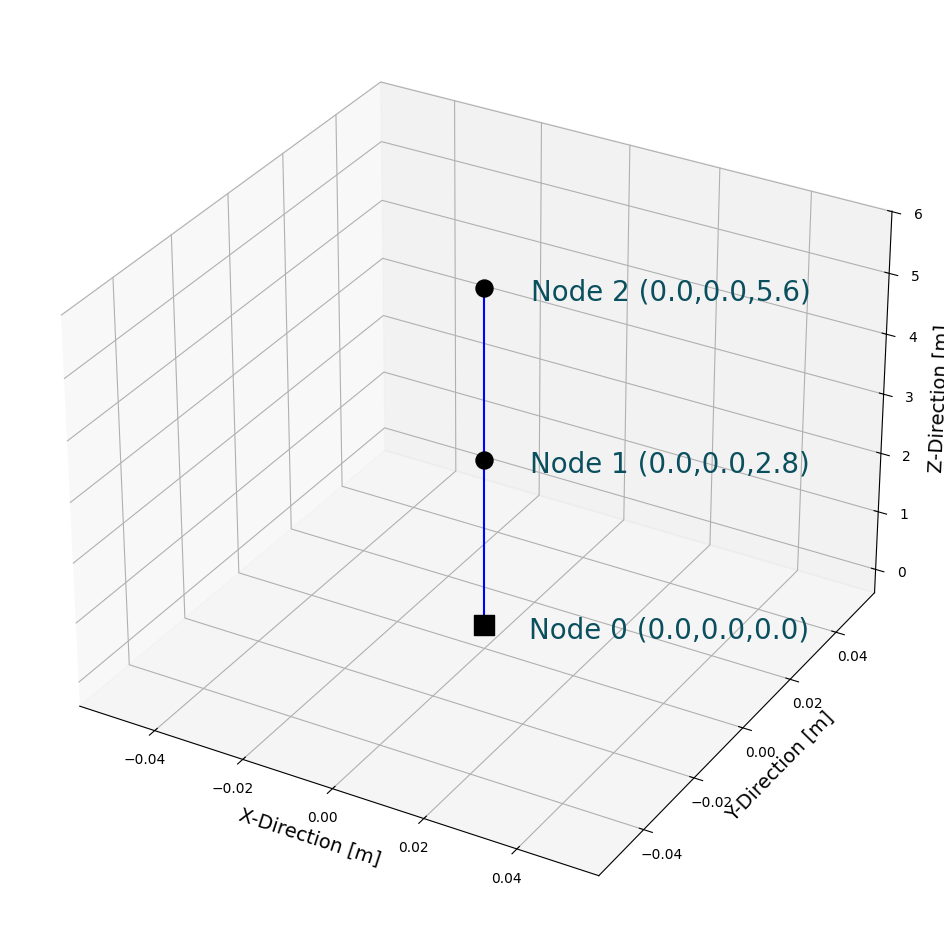

[0.1539994  0.1539994  0.06199133]
~~~~~~~ ANALYSIS SUCCESSFUL ~~~~~~~~~
Peak drift values in X-direction: [0.10898855 0.03088767] rad
Peak drift values in Y-direction: [0. 0.] rad
Peak acceleration values in X-direction: [np.float64(0.0), np.float64(0.045288979106327086), np.float64(0.04953348334780424)] g
Peak acceleration values in Y-direction: [np.float64(0.0), np.float64(0.0), np.float64(0.0)] g
Maximum peak storey drift value of 0.10898854933531987 encountered in X direction on storey # 1
Maximum peak floor acceleration value of 0.04953348334780424 encountered in X direction on storey # 2
======== MSA Analysing RP:2475 years, Record 2 out of 20 =========
[0.1539994  0.1539994  0.06199133]


WARNING ZeroLength::setDomain(): Element 2000 has L= 2.8, which is greater than the tolerance
WARNING ZeroLength::setDomain(): Element 2001 has L= 2.8, which is greater than the tolerance


~~~~~~~ ANALYSIS SUCCESSFUL ~~~~~~~~~
Peak drift values in X-direction: [0.00083294 0.0008236 ] rad
Peak drift values in Y-direction: [0. 0.] rad
Peak acceleration values in X-direction: [np.float64(0.0), np.float64(0.039041992442532585), np.float64(0.04469738311445831)] g
Peak acceleration values in Y-direction: [np.float64(0.0), np.float64(0.0), np.float64(0.0)] g
Maximum peak storey drift value of 0.000832937104355275 encountered in X direction on storey # 1
Maximum peak floor acceleration value of 0.04469738311445831 encountered in X direction on storey # 2
======== MSA Analysing RP:2475 years, Record 3 out of 20 =========
[0.1539994  0.1539994  0.06199133]


WARNING ZeroLength::setDomain(): Element 2000 has L= 2.8, which is greater than the tolerance
WARNING ZeroLength::setDomain(): Element 2001 has L= 2.8, which is greater than the tolerance


~~~~~~~ ANALYSIS SUCCESSFUL ~~~~~~~~~
Peak drift values in X-direction: [0.00282333 0.00306304] rad
Peak drift values in Y-direction: [0. 0.] rad
Peak acceleration values in X-direction: [np.float64(0.0), np.float64(0.028293670564023415), np.float64(0.03222610146383655)] g
Peak acceleration values in Y-direction: [np.float64(0.0), np.float64(0.0), np.float64(0.0)] g
Maximum peak storey drift value of 0.003063036552601405 encountered in X direction on storey # 2
Maximum peak floor acceleration value of 0.03222610146383655 encountered in X direction on storey # 2
======== MSA Analysing RP:2475 years, Record 4 out of 20 =========
[0.1539994  0.1539994  0.06199133]


...

WARNING ZeroLength::setDomain(): Element 2000 has L= 2.8, which is greater than the tolerance
WARNING ZeroLength::setDomain(): Element 2001 has L= 2.8, which is greater than the tolerance


~~~~~~~ ANALYSIS SUCCESSFUL ~~~~~~~~~
Peak drift values in X-direction: [0.00136248 0.00108877] rad
Peak drift values in Y-direction: [0. 0.] rad
Peak acceleration values in X-direction: [np.float64(0.0), np.float64(0.05217605412694148), np.float64(0.05705205902909966)] g
Peak acceleration values in Y-direction: [np.float64(0.0), np.float64(0.0), np.float64(0.0)] g
Maximum peak storey drift value of 0.0013624838240039348 encountered in X direction on storey # 1
Maximum peak floor acceleration value of 0.05705205902909966 encountered in X direction on storey # 2
======== MSA Analysing RP:2475 years, Record 20 out of 20 =========
[0.1539994  0.1539994  0.06199133]


WARNING ZeroLength::setDomain(): Element 2000 has L= 2.8, which is greater than the tolerance
WARNING ZeroLength::setDomain(): Element 2001 has L= 2.8, which is greater than the tolerance


~~~~~~~ ANALYSIS SUCCESSFUL ~~~~~~~~~
Peak drift values in X-direction: [0.00096033 0.00063903] rad
Peak drift values in Y-direction: [0. 0.] rad
Peak acceleration values in X-direction: [np.float64(0.0), np.float64(0.02791814099646406), np.float64(0.03022900572528932)] g
Peak acceleration values in Y-direction: [np.float64(0.0), np.float64(0.0), np.float64(0.0)] g
Maximum peak storey drift value of 0.0009603330541885491 encountered in X direction on storey # 1
Maximum peak floor acceleration value of 0.03022900572528932 encountered in X direction on storey # 2
======== MSA Analysing RP:4975 years, Record 1 out of 20 =========


WARNING ZeroLength::setDomain(): Element 2000 has L= 2.8, which is greater than the tolerance
WARNING ZeroLength::setDomain(): Element 2001 has L= 2.8, which is greater than the tolerance


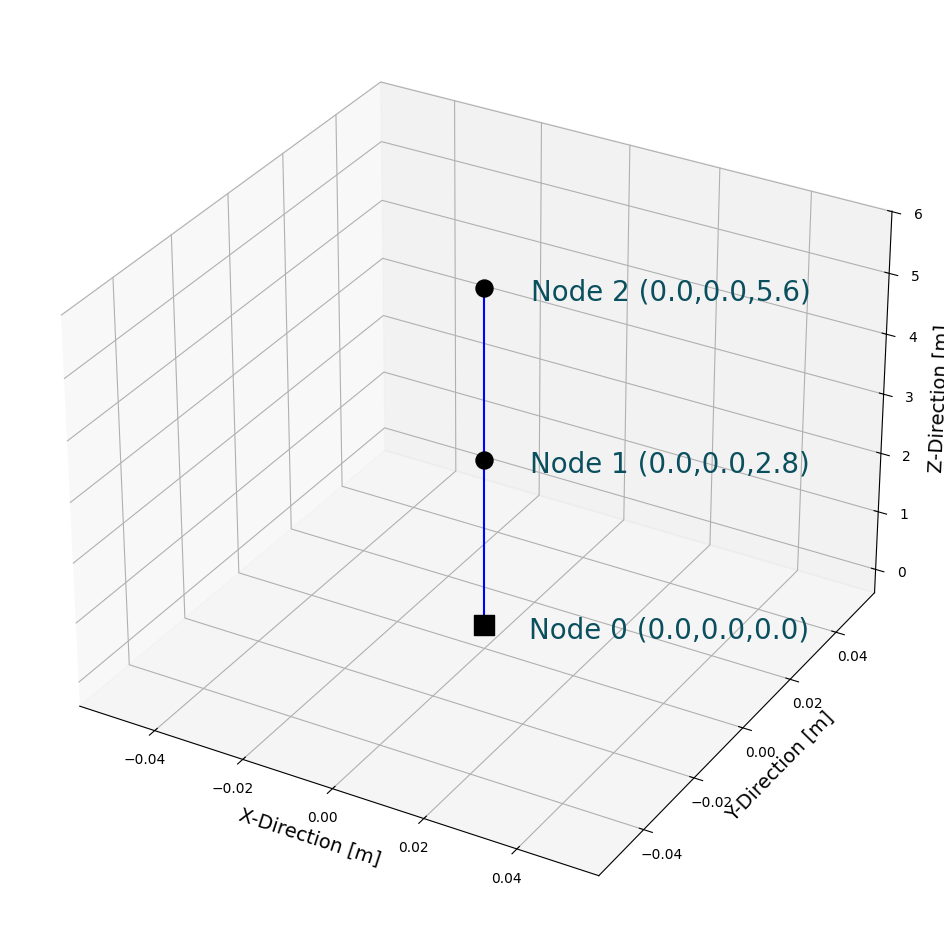

[0.1539994  0.1539994  0.06199133]
~~~~~~~ ANALYSIS SUCCESSFUL ~~~~~~~~~
Peak drift values in X-direction: [0.00148196 0.00093969] rad
Peak drift values in Y-direction: [0. 0.] rad
Peak acceleration values in X-direction: [np.float64(0.0), np.float64(0.057042202667828584), np.float64(0.07010396195200443)] g
Peak acceleration values in Y-direction: [np.float64(0.0), np.float64(0.0), np.float64(0.0)] g
Maximum peak storey drift value of 0.00148196340312212 encountered in X direction on storey # 1
Maximum peak floor acceleration value of 0.07010396195200443 encountered in X direction on storey # 2
======== MSA Analysing RP:4975 years, Record 2 out of 20 =========
[0.1539994  0.1539994  0.06199133]


WARNING ZeroLength::setDomain(): Element 2000 has L= 2.8, which is greater than the tolerance
WARNING ZeroLength::setDomain(): Element 2001 has L= 2.8, which is greater than the tolerance


~~~~~~~ ANALYSIS SUCCESSFUL ~~~~~~~~~
Peak drift values in X-direction: [0.0010735  0.00094971] rad
Peak drift values in Y-direction: [0. 0.] rad
Peak acceleration values in X-direction: [np.float64(0.0), np.float64(0.0488501679659393), np.float64(0.051101613323638766)] g
Peak acceleration values in Y-direction: [np.float64(0.0), np.float64(0.0), np.float64(0.0)] g
Maximum peak storey drift value of 0.0010734971840833214 encountered in X direction on storey # 1
Maximum peak floor acceleration value of 0.051101613323638766 encountered in X direction on storey # 2
======== MSA Analysing RP:4975 years, Record 3 out of 20 =========
[0.1539994  0.1539994  0.06199133]


WARNING ZeroLength::setDomain(): Element 2000 has L= 2.8, which is greater than the tolerance
WARNING ZeroLength::setDomain(): Element 2001 has L= 2.8, which is greater than the tolerance


~~~~~~~ ANALYSIS SUCCESSFUL ~~~~~~~~~
Peak drift values in X-direction: [0.00208398 0.00118579] rad
Peak drift values in Y-direction: [0. 0.] rad
Peak acceleration values in X-direction: [np.float64(0.0), np.float64(0.04610006397234069), np.float64(0.06278037794806858)] g
Peak acceleration values in Y-direction: [np.float64(0.0), np.float64(0.0), np.float64(0.0)] g
Maximum peak storey drift value of 0.0020839800114861866 encountered in X direction on storey # 1
Maximum peak floor acceleration value of 0.06278037794806858 encountered in X direction on storey # 2
======== MSA Analysing RP:4975 years, Record 4 out of 20 =========
[0.1539994  0.1539994  0.06199133]
~~~~~~~ ANALYSIS SUCCESSFUL ~~~~~~~~~
Peak drift values in X-direction: [0.00215638 0.00080722] rad
Peak drift values in Y-direction: [0. 0.] rad
Peak acceleration values in X-direction: [np.float64(0.0), np.float64(0.041320826848555724), np.float64(0.05459965472856214)] g
Peak acceleration values in Y-direction: [np.float64(0.0

...

~~~~~~~ ANALYSIS SUCCESSFUL ~~~~~~~~~
Peak drift values in X-direction: [0.0953019  0.04017854] rad
Peak drift values in Y-direction: [0. 0.] rad
Peak acceleration values in X-direction: [np.float64(0.0), np.float64(0.07630439015563666), np.float64(0.07536253335197181)] g
Peak acceleration values in Y-direction: [np.float64(0.0), np.float64(0.0), np.float64(0.0)] g
Maximum peak storey drift value of 0.09530189758136277 encountered in X direction on storey # 1
Maximum peak floor acceleration value of 0.07630439015563666 encountered in X direction on storey # 1
======== MSA Analysing RP:4975 years, Record 19 out of 20 =========
[0.1539994  0.1539994  0.06199133]


WARNING ZeroLength::setDomain(): Element 2000 has L= 2.8, which is greater than the tolerance
WARNING ZeroLength::setDomain(): Element 2001 has L= 2.8, which is greater than the tolerance


~~~~~~~ ANALYSIS SUCCESSFUL ~~~~~~~~~
Peak drift values in X-direction: [0.00472843 0.00306125] rad
Peak drift values in Y-direction: [0. 0.] rad
Peak acceleration values in X-direction: [np.float64(0.0), np.float64(0.056906965715002936), np.float64(0.07089670778984547)] g
Peak acceleration values in Y-direction: [np.float64(0.0), np.float64(0.0), np.float64(0.0)] g
Maximum peak storey drift value of 0.004728425063177622 encountered in X direction on storey # 1
Maximum peak floor acceleration value of 0.07089670778984547 encountered in X direction on storey # 2
======== MSA Analysing RP:4975 years, Record 20 out of 20 =========
[0.1539994  0.1539994  0.06199133]


WARNING ZeroLength::setDomain(): Element 2000 has L= 2.8, which is greater than the tolerance
WARNING ZeroLength::setDomain(): Element 2001 has L= 2.8, which is greater than the tolerance


~~~~~~~ ANALYSIS SUCCESSFUL ~~~~~~~~~
Peak drift values in X-direction: [0.02715275 0.0022246 ] rad
Peak drift values in Y-direction: [0. 0.] rad
Peak acceleration values in X-direction: [np.float64(0.0), np.float64(0.041572176797339724), np.float64(0.042408258436165074)] g
Peak acceleration values in Y-direction: [np.float64(0.0), np.float64(0.0), np.float64(0.0)] g
Maximum peak storey drift value of 0.027152748049019827 encountered in X direction on storey # 1
Maximum peak floor acceleration value of 0.042408258436165074 encountered in X direction on storey # 2
ANALYSIS COMPLETED!


In [7]:
# Initialise the hierarchical dictionary
ansys_dict = {}

# Loop over return periods
for current_rp in RP:

    # Current return period folder
    current_rp_folder = os.path.join(gm_directory, str(current_rp))

    # Load ground-motion data: acceleration time-histories, time-steps and durations
    gmrs = np.loadtxt(os.path.join(current_rp_folder, 'GMR_H1_names.txt'), dtype=str)
    dts  = np.loadtxt(os.path.join(current_rp_folder, 'GMR_dts.txt'), dtype=float)

    # Initialise storage for this return period
    ansys_dict[current_rp] = {'T': None,
                              'conv_index_list': [],
                              'peak_disp_list': [],
                              'peak_drift_list': [],
                              'peak_accel_list': [],
                              'max_peak_drift_list': [],
                              'max_peak_drift_dir_list': [],
                              'max_peak_drift_loc_list': [],
                              'max_peak_accel_list': [],
                              'max_peak_accel_dir_list': [],
                              'max_peak_accel_loc_list': []}
    
    # Loop over ground-motion records
    for i in range(len(gmrs)):
        print('================================================================')
        print('======== MSA Analysing RP:{:s} years, Record {:d} out of {:d} ========='.format(current_rp, i+1, len(gmrs)))
        print('================================================================')

        # Initialise the modeller class and compile the MDOF model 
        model = modeller(number_storeys, 
                         floor_heights, 
                         floor_masses,
                         storey_disps, 
                         storey_forces*units.g, 
                         mdof_degradation)
        model.compile_model()

        # Plot the model only for the first ground-motion record
        if i == 0:
            model.plot_model()        

        # Do gravity analysis for system equilibrium
        model.do_gravity_analysis()

        # Do modal analysis
        num_modes = 1 if number_storeys == 1 else 3
        T, phi = model.do_modal_analysis(num_modes=num_modes, plot_modes=False)
        print(T)
    
        # Define ground motion objects
        fnames   = [os.path.join(current_rp_folder, f'{gmrs[i]}')]
        current_acc = np.loadtxt(os.path.join(current_rp_folder, gmrs[i]))   # Load the acceleration (only to calculate the duration)
        dt_gm = dts[i]                                                       # Get the time-step           
        t_max = len(current_acc) * dt_gm                                     # Get the maximum duration
        dt_ansys = dt_gm                                                     # Set the analysis time-step equal to the ground-motion time-step
    
        # Run Multiple Stripe Analysis:
        # There is no dedicated function in OQ-VMTK for MSA, instead we are calling the do_nrha_analysis
        # method from the modeller class for each record at each return period
        control_nodes, conv_index, peak_drift, peak_accel, max_peak_drift, max_peak_drift_dir, max_peak_drift_loc, max_peak_accel, max_peak_accel_dir, max_peak_accel_loc, peak_disp = model.do_nrha_analysis(fnames, 
                                                                                                                                                                                                              dt_gm, 
                                                                                                                                                                                                              units.g, 
                                                                                                                                                                                                              t_max, 
                                                                                                                                                                                                              dt_ansys,
                                                                                                                                                                                                              pFlag=False,
                                                                                                                                                                                                              xi = 0.05) 

        # Print statements
        print('Peak drift values in X-direction:', peak_drift[:,0], 'rad') # Peak drift values in the X-direction
        print('Peak drift values in Y-direction:', peak_drift[:,1], 'rad') # Peak drift values in the Y-direction (Zeros due to uni-directional loading)
        print('Peak acceleration values in X-direction:', [x/9.81 for x in peak_accel[:,0]], 'g') # Peak acceleration values in the X-direction (converted to g)
        print('Peak acceleration values in Y-direction:', [x/9.81 for x in peak_accel[:,1]], 'g') # Peak acceleration values in the Y-direction (converted to g)
        print('Maximum peak storey drift value of', max_peak_drift, 'encountered in', max_peak_drift_dir ,'direction', 'on storey #', max_peak_drift_loc)       # Reporting
        print('Maximum peak floor acceleration value of', max_peak_accel/9.81, 'encountered in', max_peak_accel_dir ,'direction', 'on storey #', max_peak_accel_loc) # Reporting
        
        # Store results in hierarchical dict
        ansys_dict[current_rp]['conv_index_list'].append(conv_index)
        ansys_dict[current_rp]['peak_drift_list'].append(peak_drift)
        ansys_dict[current_rp]['peak_accel_list'].append(peak_accel)
        ansys_dict[current_rp]['peak_disp_list'].append(peak_disp)
        ansys_dict[current_rp]['max_peak_drift_list'].append(max_peak_drift)
        ansys_dict[current_rp]['max_peak_drift_dir_list'].append(max_peak_drift_dir)
        ansys_dict[current_rp]['max_peak_drift_loc_list'].append(max_peak_drift_loc)
        ansys_dict[current_rp]['max_peak_accel_list'].append(max_peak_accel)
        ansys_dict[current_rp]['max_peak_accel_dir_list'].append(max_peak_accel_dir)
        ansys_dict[current_rp]['max_peak_accel_loc_list'].append(max_peak_accel_loc)

# Export the results
export_to_pkl(os.path.join(msa_directory, 'msa_ansys_out.pkl'), ansys_dict)

print('ANALYSIS COMPLETED!')

## Pre-Process Intensity Measure Levels and Engineering Demand Parameters for MSA Post-Processor ##

In [8]:
# Determine dimensions
num_stripes = len(RP)                      # The number of stripes equals the number of return periods considered
num_gmrs = len(imls[RP[0]]['SA(0.19)'])  # The number of ground-motion is equal across all return periods (so we can simply take the length of the first RP IML values)

# Initialize empty arrays
imls_matrix = np.zeros((num_gmrs, num_stripes))
edps_matrix = np.zeros((num_gmrs, num_stripes))

# Loop over RPs to fill the columns
for j, rp in enumerate(RP):
    # Use the dictionary (imls) to fill the array (imls_matrix)
    imls_matrix[:, j] = imls[rp][IMT[0]]                           # The input is the name of the key associated with the IMT (IMT[0] = 'SA(0.2)') 
    edps_matrix[:, j] = ansys_dict[rp]['max_peak_drift_list']      # Options are: 'max_peak_drift_list' or 'max_peak_accel_list'

## Post-Process Multiple Stripe Results: Maximum Likelihood Estimation and Fragility Functions ##

**Multiple Stripe Analysis** [1,2] is an efficient computational procedure used to assess the seismic performance of structures at discrete levels of intensity. MSA serves as an alternative to Incremental Dynamic Analysis (IDA) or Cloud Analysis (CA). While IDA relies on the scaling of a single record until global dynamic instability and unlike CA which utilizes a suite of unscaled "natural" records, MSA involves using a set of hazard-consistent ground motion ensembles [3] at specific intensity measure (IM) levels, or "stripes". These stripes typically correspond to distinct hazard levels, such as specific return periods or targets defined by an "approximate" or "exact" Conditional Mean Spectrum (CMS) [4] in tandem with the results of seismic hazard disaggregation [5]. The CMS can be calculated using the OpenQuake Engine [7,8]. Additional information, such as examples and documentation, on performing hazard disaggregation in OpenQuake is available in the official repository (accessible on: https://github.com/gem/oq-engine/tree/master/openquake/qa_tests_data/conditional_spectrumn) and documentation (accessible on: https://docs.openquake.org/oq-engine/LTS/manual/user-guide/advanced/advanced-calculations.html), respectively. The primary output of MSA for fragility assessment is a set of discrete data points: at each intensity level , a total of  ground motions are analyzed, and the number of cases  exceeding a specific damage state (e.g., collapse) is recorded.

A primary advantage of MSA is its ability to explicitly decouple the intensity measure from the record-selection process at each hazard level. This allows researchers to account for the evolution of spectral shape and ground motion characteristics (e.g., epsilon, duration) as seismic intensity increases. By analyzing structural response distributions at these discrete intervals, MSA captures the aleatory uncertainty (record-to-record variability) and provides the statistical basis for deriving fragility functions through Maximum Likelihood Estimation (MLE) [6].

### Fragility Function Derivation using Maximum Likelihood Estimation (MLE) ###

To translate these discrete observations into a continuous, statistically robust fragility function, Maximum Likelihood Estimation (MLE) is employed. This approach, as detailed by Baker [4], treats the structural response at each stripe as a series of Bernoulli trials, where the outcome is either exceeding or not exceeding a specific limit state.

#### Step 1: The Lognormal Distribution Assumption #### 

The fragility function represents the probability of exceeding a damage state ($DS$) conditioned on the intensity measure ($IM$). It is conventionally modeled using a lognormal cumulative distribution function (CDF):$$P(DS \ge ds \mid IM = im) = \Phi \left( \frac{\ln(im / \theta)}{\beta} \right)$$ where: 
* $\theta$ is the median capacity (the intensity level with a 50% probability of exceedance)
* $\beta$ is the logarithmic standard deviation (dispersion) representing record-to-record variability
* $\Phi(\cdot)$ denotes the standard normal cumulative distribution function.

#### Step 2: Formulating the Likelihood Function #### 

The objective of MLE is to find the parameters $\theta$ and $\beta$ that maximize the likelihood of observing the data obtained from the MSA. For a set of $m$ stripes, the likelihood function $\mathcal{L}$ is the product of the binomial probabilities for each stripe:$$\mathcal{L} = \prod_{j=1}^{m} \binom{n_j}{z_j} \left[ \Phi \left( \frac{\ln(im_j / \theta)}{\beta} \right) \right]^{z_j} \left[ 1 - \Phi \left( \frac{\ln(im_j / \theta)}{\beta} \right) \right]^{n_j - z_j}$$In practice, it is numerically more stable to maximize the log-likelihood ($\ln \mathcal{L}$), which converts the product into a sum:$$\ln \mathcal{L} = \sum_{j=1}^{m} \left\{ \ln \binom{n_j}{z_j} + z_j \ln \left[ \Phi \left( \frac{\ln(im_j / \theta)}{\beta} \right) \right] + (n_j - z_j) \ln \left[ 1 - \Phi \left( \frac{\ln(im_j / \theta)}{\beta} \right) \right] \right\}$$

#### Step 3: Optimization and Total Uncertainty #### 

The optimal estimates for the median ($\hat{\theta}$) and dispersion ($\hat{\beta}$) are obtained by solving the optimization problem that maximizes the log-likelihood function. This method is particularly robust because it utilizes the full data set, including stripes where zero or all records exceed the damage state, without the bias inherent in extrapolating regressions from non-collapse data.The total dispersion $\beta_{ds_i}^{\text{total}}$ is then computed by incorporating epistemic uncertainties using the root sum of squares (SRSS):$$\beta_{ds_i}^{\text{total}} = \sqrt{\beta_{\text{record-to-record}}^2 + \beta_{\text{building-to-building}}^2 + \beta_{\text{DS}}^2}$$ where: 
* $\beta_{\text{record-to-record}}$ is the dispersion derived from the record-to-record variability in the MSA
* $\beta_{\text{building-to-building}}$ accounts for modeling uncertainty
* $\beta_{\text{DS}}$ accounts for uncertainty in the damage state thresholds

In [13]:
# Damage thresholds (maximum peak storey drift values in rad)
damage_thresholds    =  [0.00150, 0.00545, 0.00952, 0.0135]  # Note: The damage thresholds are arbitrary and are not associated with any limit state analysis

# Initialise the postprocessor class
pp = postprocessor()

# Call the "do_multiple_stripe_analysis" method from the postprocessor class
msa_dict = pp.do_multiple_stripe_analysis(imls_matrix,
                                          edps_matrix,
                                          damage_thresholds,
                                          sigma_build2build=0.3,
                                          intensities=np.round(np.geomspace(0.05, 10.0, 50), 3),
                                          fragility_rotation=False,
                                          rotation_percentile=0.10)


## Visualise Multiple Stripe Analysis Results: Stripes, Fragility Functions ##

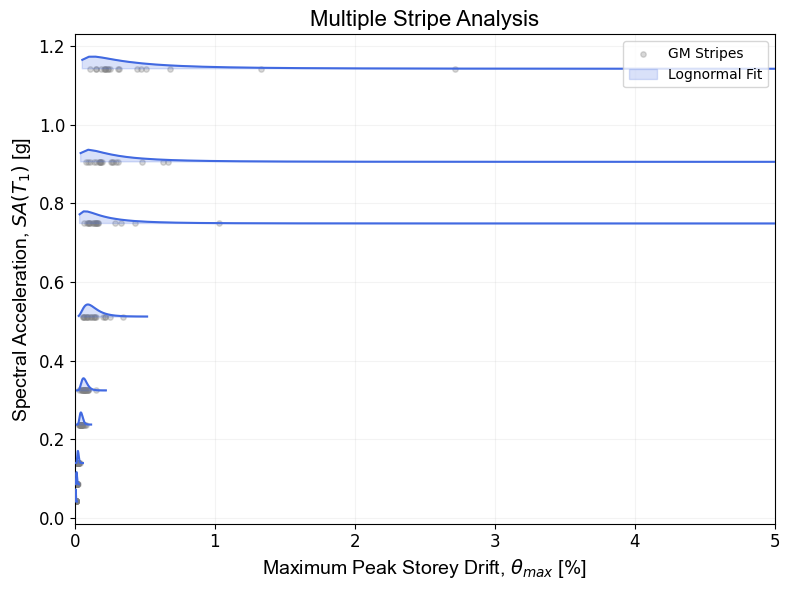

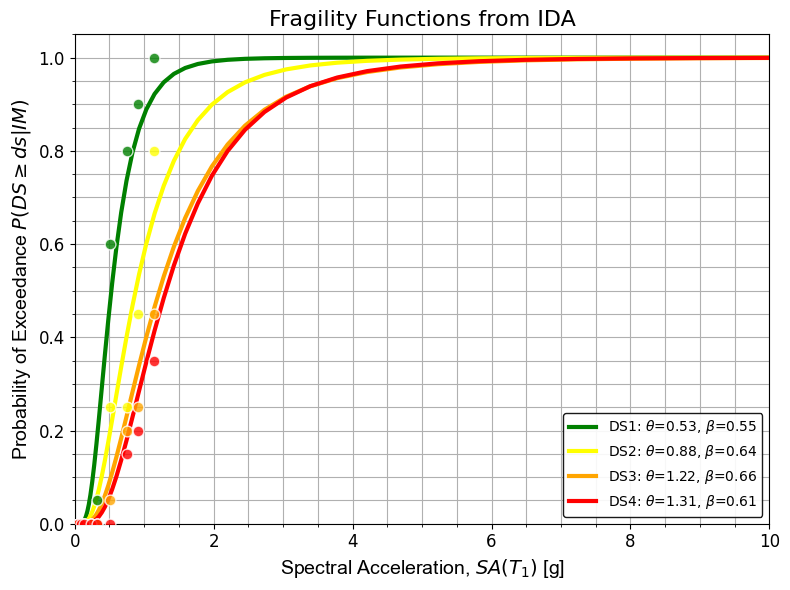

In [10]:
# Initialise the plotter class
pl=plotter()

# Plot the IDA curves
pl.plot_msa_analysis(imls_matrix,
                     edps_matrix,
                     imt_label   = r'Spectral Acceleration, $SA(T_{1})$ [g]',
                     edp_label   = r'Maximum Peak Storey Drift, $\theta_{max}$ [%]',
                     title       = 'Multiple Stripe Analysis',
                     pFlag       = True,
                     export_path = 'out/figures/msa_stripes.png')

pl.plot_fragility_from_msa(msa_dict,
                           imt_label = r'Spectral Acceleration, $SA(T_{1})$ [g]',
                           title = 'Fragility Functions from IDA',
                           pFlag = True,
                           export_path = 'figures/fragility_curves.png')

## Post-Process Building-Level Vulnerability Functions based on Fragility Functions and Consequence Models ###

### Expected Loss Ratio (Mean Damage Ratio)

The vulnerability function expresses the expected loss ratio as a function of an intensity measure level (IM) and is obtained by convolving fragility functions with damage-to-loss ratios associated with each damage state.
Let $P(DS = ds_i \mid IM)$ denote the probability of the structure being in damage state $ds_i$ at a given intensity measure level $IM$, and let $\mu_{LR,i}$ be the mean loss ratio associated with that damage state. The expected loss ratio at intensity level $IM$, denoted as $E[LR \mid IM]$, is defined as

$$
E[LR \mid IM] = 
\sum_{i=1}^{N_{DS}}
P(DS = ds_i \mid IM),\mu_{LR,i}
$$

where:

* $N_{DS}$ is the total number of discrete damage states
* $P(DS = ds_i \mid IM)$ is derived from the fragility functions
* $\mu_{LR,i}$ is the mean loss ratio associated with damage state $ds_i$


#### Step 1: Calculate Damage-State Probabilities (i.e., Probabilities of Occurrence) from Fragility Functions

Fragility functions are commonly expressed in terms of probabilities of exceedance. The probability of being in a specific damage state is computed as

$$
P(DS = ds_i \mid IM) =
\begin{cases}
P(DS \ge ds_i \mid IM) - P(DS \ge ds_{i+1} \mid IM), & i < N_{DS} \
P(DS \ge ds_{N_{DS}} \mid IM), & i = N_{DS}
\end{cases}
$$

Assuming lognormal fragility functions, the probability of exceeding damage state $ds_i$ is given by

$$
P(DS \ge ds_i \mid IM) = 
\Phi\left(
\frac{\ln(IM) - \ln(\mu_{ds_i})}
{\beta_{ds_i}^{\text{total}}}
\right)
$$

where:

* $\mu_{ds_i}$ is the median intensity measure corresponding to damage state $ds_i$
* $\beta_{ds_i}^{\text{total}}$ is the total logarithmic standard deviation
* $\Phi(\cdot)$ is the standard normal cumulative distribution function

The total dispersion is computed as

$$
\beta_{ds_i}^{\text{total}} = 
\sqrt{
\beta_{\text{record-to-record}}^2
+
\beta_{\text{building-to-building}}^2
+
\beta_{\text{DS}}^2
}
$$

where:

* $\beta_{\text{record-to-record}}$ (or $\beta_{\text{EDP}\mid IM}$) represents ground-motion variability
* $\beta_{\text{building-to-building}}$ (or $\beta_{\text{MDL}}$) captures model and structural variability
* $\beta_{\text{DS}}$ represents uncertainty in damage-state definition and thresholds


#### Step 2: Calculation of Uncertainty in Expected Loss

#### Method 1: Silva [5] (Semi-Empirical)

When uncertainty in the damage-to-loss relationship is not explicitly modelled, the dispersion of the loss ratio conditional on the intensity measure can be estimated using the empirical formulation proposed by Silva [5].
The coefficient of variation of the loss ratio conditional on $IM$ is defined as

$$
\mathrm{COV}(LR \mid IM) = 
\frac{\sigma_{LR \mid IM}}{E[LR \mid IM]}
$$

Following Silva [5], the standard deviation of the loss ratio is expressed as a function of the mean loss ratio:

$$
\sigma_{LR \mid IM} = 
0.5
\sqrt{
\overline{LR}_{\mid IM}
\left(
-0.7
* 2,\overline{LR}_{\mid IM}
- \sqrt{6.8,\overline{LR}_{\mid IM} + 0.5}
  \right)
  }
$$

where $\overline{LR}_{\mid IM}$ denotes the mean loss ratio conditional on the intensity measure level. This approach provides a conservative envelope for loss uncertainty and is commonly adopted when detailed loss information is unavailable.


#### Method 2: Explicit Statistical Propagation

Alternatively, the uncertainty in the expected loss ratio can be quantified by explicitly propagating uncertainty through the convolution of damage-state probabilities and damage-to-loss ratios. In this formulation, fragility functions account for uncertainty in structural response and damage-state thresholds, while additional uncertainty arises from variability in the damage-to-loss ratios associated with each damage state. The expected loss ratio conditional on $IM$ is given by

$$
E[LR \mid IM] = 
\sum_{i=1}^{N_{DS}}
P(DS = ds_i \mid IM),\mu_{LR,i}
$$

Assuming the loss ratio conditional on each damage state is an independent random variable with coefficient of variation $\mathrm{COV}_{LR,i}$, the variance of the loss ratio conditional on $IM$ is computed using the **law of total variance**:

$$
\mathrm{Var}(LR \mid IM) = 
\sum_{i=1}^{N_{DS}}
P(DS = ds_i \mid IM)
\left[
\sigma_{LR,i}^2
+
\left(
\mu_{LR,i} - E[LR \mid IM]
\right)^2
\right]
$$

where

$$
\sigma_{LR,i} =
\mathrm{COV}*{LR,i},\mu*{LR,i}
$$

The coefficient of variation of the loss ratio conditional on the intensity measure is then computed as

$$
\mathrm{COV}(LR \mid IM) = 
\frac{
\sqrt{\mathrm{Var}(LR \mid IM)}
}{
E[LR \mid IM]
}
$$

This formulation captures both:

* uncertainty **within damage states** due to variability in damage-to-loss ratios, and
* uncertainty due to **damage-state mixing** as intensity varies.


### Note on Beta-Distribution Interpretation of the Vulnerability Function

The loss ratio conditional on intensity measure level $IM$ is assumed to follow a **Beta distribution** as one option in the OpenQuake Engine <dist='BT'> (https://docs.openquake.org/oq-engine/3.23/manual/user-guide/inputs/vulnerability-models-inputs.html), owing to its bounded support on the interval $[0,1]$ and its flexibility in representing skewed distributions.

$$
LR \mid IM \sim \mathrm{Beta}(\alpha(IM), \beta(IM))
$$

The Beta distribution parameters are obtained by matching the first two moments:

$$
\mu(IM) = E[LR \mid IM]
$$

$$
\sigma^2(IM) = \mathrm{Var}(LR \mid IM)
$$

Defining the precision parameter

$$
\kappa(IM) = \alpha(IM) + \beta(IM)
$$

the Beta parameters are computed as

$$
\kappa(IM) =
\frac{\mu(IM),[1-\mu(IM)]}{\sigma^2(IM)} - 1
$$

$$
\alpha(IM) = \mu(IM),\kappa(IM),
\qquad
\beta(IM) = [1-\mu(IM)],\kappa(IM)
$$

This assumption enables a complete probabilistic characterization of loss conditional on intensity measure level and is particularly suitable for risk calculations, loss aggregation, and Monte Carlo simulation within performance-based engineering frameworks.

In [11]:
# Define consequence model to relate structural damage to a decision variable (i.e., expected loss ratio) 
consequence_model = [0.05, 0.20, 0.60, 1.00] # damage-to-loss ratios

# Define the uncertainty associated with each damage-to-loss ratio via coefficients of variation
consequence_cov = [0.30, 0.25, 0.20, 0.00] 

# Calculate the structural vulnerability function (using the explicit method)
structural_vulnerability_explicit_cov = pp.calculate_vulnerability_function(msa_dict['fragility']['poes'][:,:4],  # Use the poes output (columns 1 to 4 > DS1 to DS4)
                                                                            consequence_model,                      # The consequence model representing the normalised loss ratios per damage state
                                                                            cov_consequence = consequence_cov,      # The coefficient of variation model representing the uncertainty around the loss ratios per damage state
                                                                            uncertainty=True,                       # Set uncertainty equal to True to calculate COV of the Beta Distribution
                                                                            method='explicit')                      # Set method to explicit for COV calculation per law of total variance         

# Calculate the structural vulnerability function (using the explicit method)
structural_vulnerability_silva_cov = pp.calculate_vulnerability_function(msa_dict['fragility']['poes'][:,:4],  # Use the poes output (columns 1 to 4 > DS1 to DS4)
                                                                         consequence_model,                      # The consequence model representing the normalised loss ratios per damage state
                                                                         uncertainty=True,                       # Set uncertainty equal to True to calculate COV of the Beta Distribution
                                                                         method='silva')                         # Set method to Silva for semi-empirical COV calculation     

## Plot the Vulnerability Functions with Uncertainty Visualisation ##

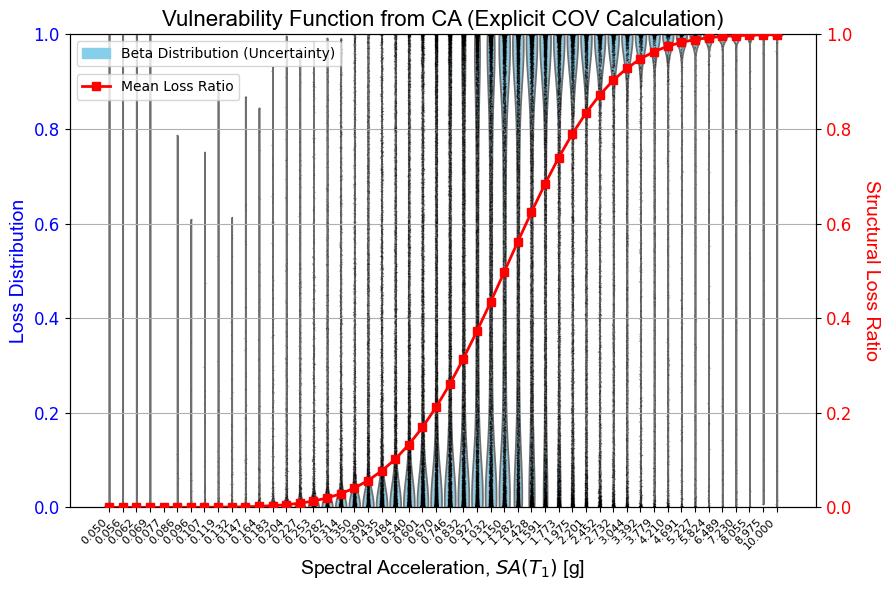

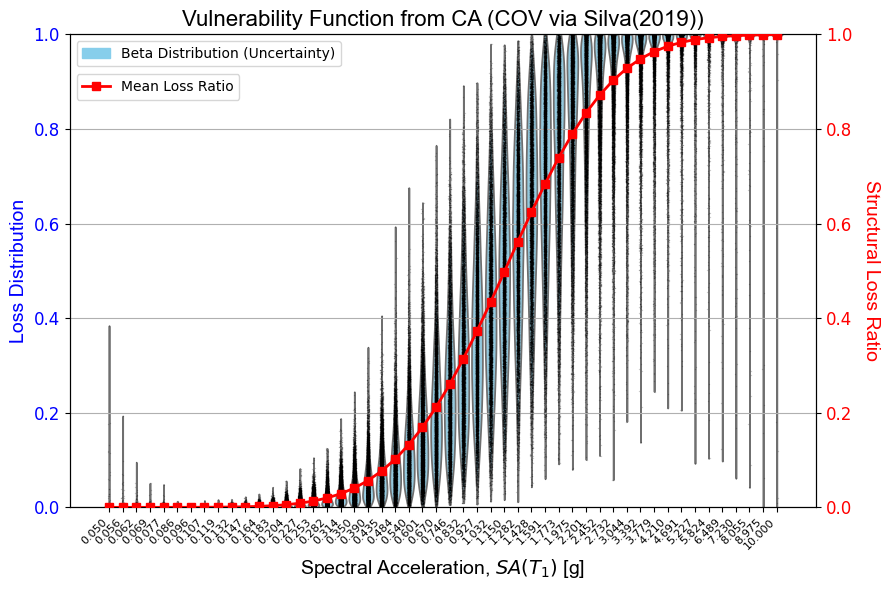

In [12]:
# Plot the structural vulnerability function from the explicit COV method
pl.plot_vulnerability_function(structural_vulnerability_explicit_cov['IML'],
                               structural_vulnerability_explicit_cov['Loss'],
                               structural_vulnerability_explicit_cov['COV'],
                               imt_label   = r'Spectral Acceleration, $SA(T_{1})$ [g]',
                               ylabel      = 'Structural Loss Ratio',
                               title       = 'Vulnerability Function from CA (Explicit COV Calculation)',
                               pFlag       = True,
                               export_path = 'out/figures/vulnerability_curve_explicit_cov.png')

# Plot the structural vulnerability function from the 'Silva (2019)' method
pl.plot_vulnerability_function(structural_vulnerability_silva_cov['IML'],
                               structural_vulnerability_silva_cov['Loss'],
                               structural_vulnerability_silva_cov['COV'],
                               imt_label   = r'Spectral Acceleration, $SA(T_{1})$ [g]',
                               ylabel      = 'Structural Loss Ratio',
                               title       = 'Vulnerability Function from CA (COV via Silva(2019))',
                               pFlag       = True,
                               export_path = 'out/figures/vulnerability_curve_silva_cov.png')